# YouTube Video Data - Exploratory Data Analysis - (Enhanced Feature Set)

This notebook presents an exploratory data analysis of an enhanced YouTube video dataset that extends the original crawl-level data with platform-native and creator-level features retrieved via the YouTube Data API. In addition to technical encoding attributes and surface metadata, the enriched dataset incorporates temporal information, standardized engagement metrics, channel-level social capital indicators, and platform context variables.

The analysis proceeds through a systematic assessment of data quality and coverage, followed by univariate and bivariate exploration of video-level, channel-level, and engagement-related features. Particular attention is given to distinguishing content attributes from exposure-driven factors, enabling clearer interpretation of how creator popularity, publication timing, and platform context interact with observed engagement outcomes. Where applicable, derived metrics and normalized representations are examined to support downstream statistical modeling.

Overall, this notebook serves to characterize the expanded feature space, highlight structural differences relative to the original dataset, and inform subsequent modeling decisions by clarifying which signals are intrinsic to content and which primarily reflect post-publication diffusion dynamics.

---
## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)

# Plot style - modern and readable
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except (OSError, ValueError):
    try:
        plt.style.use('seaborn-whitegrid')
    except (OSError, ValueError):
        pass
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load data
df = pd.read_csv('/Users/maxchalekson/Northwestern University/Winter-2026/MSDS-422-0/Final-Project/422-final-project/youtube_data_enriched.csv')
df_raw = df.copy()

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head(10)

Dataset shape: 17,589 rows × 45 columns
Memory usage: 40.48 MB


,video_id,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),codec,category,url,title,description,hashtags,views,likes,comments,yt_title,yt_description,yt_published_at,yt_duration_sec,yt_category_id,yt_tags_json,yt_default_language,yt_default_audio_language,yt_made_for_kids,yt_live_broadcast_content,yt_view_count,yt_like_count,yt_comment_count,yt_channel_id,yt_thumb_url,yt_thumb_quality,yt_channel_title,yt_channel_published_at,yt_channel_country,yt_subscriber_count,yt_channel_view_count,yt_channel_video_count,thumb_path,thumb_sha1,thumb_width,thumb_height,thumb_mean_brightness,thumb_colorfulness
0,--F7dc-_FSI,180,5777,5640,1920,1080,25.00,25.00,h264,News & Politics,https://www.youtube.com/watch?v=--F7dc-_FSI,«السودان ينتفض» أمام السفارة بالقاهرة,حرية سلام وعدالة، الثورة خيار الشعب.. بهذا الهتاف تجمع ع...,"في, عسكري, حكم, حرية, بخصوص, المصري اليوم, السودان, قوات...",4078,41,3,«السودان ينتفض» أمام السفارة بالقاهرة,حرية سلام وعدالة، الثورة خيار الشعب.. بهذا الهتاف تجمع ع...,2012-07-08T14:37:50Z,180.0,25.0,"[""\u0627\u0644\u0633\u0648\u062f\u0627\u0646"", ""\u062b\u...",ar,ar,False,none,4133.0,41.0,3.0,UCP4rilfFKdjXRC1guWNZ85g,https://i.ytimg.com/vi/--F7dc-_FSI/maxresdefault.jpg,maxres,AlmasryAlyoum المصري اليوم,2009-05-15T10:50:11Z,EG,1560000.0,781415502.0,52983.0,/Users/maxchalekson/Northwestern University/Winter-2026/...,2ff9d97b64fb57e8e34a32149ce79a5d4e06d09f,1280.0,720.0,140.418808,43.340469
1,--cCAD-8Y_U,930,1195,1001,1280,720,30.00,30.00,h264,Gaming,https://www.youtube.com/watch?v=--cCAD-8Y_U,Pokemon Tower Defense Episodio 2,Espero que tenham gostado do video!,"Pokémon (Anime/Manga Franchise), Pokémon (Video Game Ser...",33,2,1,Pokemon Tower Defense Episodio 2,Espero que tenham gostado do video!,2013-06-30T12:22:51Z,930.0,20.0,"[""Pok\u00e9mon (Video Game Series)"", ""Tower Defense (Med...",pt-PT,pt-PT,False,none,63.0,3.0,1.0,UCzs1-4by_rmAcvApBZIXQfQ,https://i.ytimg.com/vi/--cCAD-8Y_U/maxresdefault.jpg,maxres,Hugo Oliveira,2011-07-25T21:44:48Z,PT,23.0,2115.0,33.0,/Users/maxchalekson/Northwestern University/Winter-2026/...,40093a4cf46d9c594b5b8a0b6e07d75da788c2b4,1280.0,720.0,109.450752,69.939587
2,--g2gG8pQ0w,233,3028,2833,1280,720,23.98,23.98,h264,Comedy,https://www.youtube.com/watch?v=--g2gG8pQ0w,New Hip Hop - Kemo Treats - Pancakes,Download all our music for FREE just enter $0. http://ke...,"breaking bad spoof, Recipes, Pancakes, canada, Cook, fun...",13227,135,17,New Hip Hop - Kemo Treats - Pancakes,Download all our music for FREE just enter $0.\nhttp://k...,2012-12-01T17:47:33Z,232.0,23.0,"[""Pancakes"", ""kemo treats"", ""breaking bad"", ""hip hop"", ""...",en,en,False,none,13278.0,135.0,17.0,UCZxFqnN4JxPgNMB22KCNgmA,https://i.ytimg.com/vi/--g2gG8pQ0w/maxresdefault.jpg,maxres,KEMOTREATS,2010-05-08T18:33:52Z,NaN,163.0,48752.0,17.0,/Users/maxchalekson/Northwestern University/Winter-2026/...,84dd9d08eeb96749b2b13679a6ea7a1fd1ea92fc,1280.0,720.0,101.439758,39.259814
3,-0DR7-voRCU,562,431,300,320,240,29.97,0.00,h264,People & Blogs,https://www.youtube.com/watch?v=-0DR7-voRCU,Sister's Keeper Impression,A Review of the Shampoo Bar(Sunburst) and Dip Moisturizer,"natural hair, first impression, sister's keeper products...",43,1,0,Sister's Keeper Impression,A Review of the Shampoo Bar(Sunburst) and Dip Moisturizer,2013-07-16T21:52:13Z,562.0,22.0,"[""natural hair"", ""sister's keeper products"", ""Dip hair a...",en,en,False,none,51.0,1.0,0.0,UC5ZkH4lB9PrpU--hsj7APBw,https://i.ytimg.com/vi/-0DR7-voRCU/hqdefault.jpg,high,Tenaciously Tamika,2006-08-26T15:13:13Z,US,194.0,19104.0,167.0,/Users/maxchalekson/Northwestern University/Winter-2026/...,7af922141e1cb7d55efb53c7e6e32498a786d359,480.0,360.0,134.669174,26.630418
4,-0Fkp-2EzX0,300,3087,2929,1280,720,23.98,23.98,h264,Gaming,https://www.youtube.com/watch?v=-0Fkp-2EzX0,JBHAMMER777 (AKUMA) VS KtossPol Rank 1 (Vega) VS ma Chi...,JBHAMMER777 is he strong enough to fight against Tokido ...,"Tokido, momochi, (Ryu), AE, 11, at, Piyoppia, Street, Ki...",222,2,0,JBHAMM

---
## 2. Data Quality & Profiling

### 2.1 Basic Schema & Data Types

In [2]:
# Column info with details
def get_sample(col):
    try:
        if df[col].notna().any():
            return str(df[col].dropna().iloc[0])[:40]
    except (IndexError, KeyError):
        pass
    return 'N/A'

schema = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.count().values,
    'Unique': [df[col].nunique() for col in df.columns],
    'Sample': [get_sample(col) for col in df.columns]
})
schema

,Column,Dtype,Non-Null,Unique,Sample
0,video_id,object,17589,17589,--F7dc-_FSI
1,duration,int64,17589,1320,180
2,bitrate,int64,17589,3512,5777
3,bitrate(video),int64,17589,3444,5640
4,height,int64,17589,266,1920
5,width,int64,17589,172,1080
6,frame rate,float64,17589,467,25.0
7,frame rate(est.),float64,17589,259,25.0
8,codec,object,17589,4,h264
9,category,object,17589,16,News & Politics


### 2.2 Missing Values Analysis

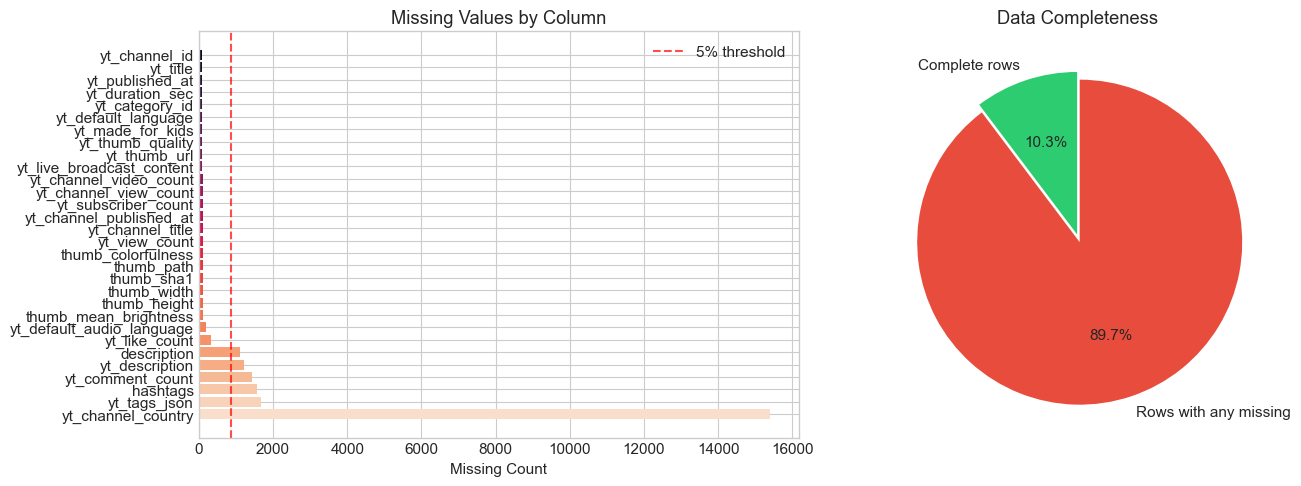

,Missing,Pct (%)
yt_channel_country,15397,87.54
yt_tags_json,1670,9.49
hashtags,1576,8.96
yt_comment_count,1429,8.12
yt_description,1205,6.85
description,1112,6.32
yt_like_count,314,1.79
yt_default_audio_language,192,1.09
thumb_mean_brightness,106,0.60
thumb_height,106,0.60


In [3]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing values
if len(missing_df) > 0:
    bars = axes[0].barh(missing_df.index, missing_df['Missing'], color=sns.color_palette('rocket_r', len(missing_df)))
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values by Column')
    axes[0].axvline(x=len(df)*0.05, color='red', linestyle='--', alpha=0.7, label='5% threshold')
    axes[0].legend()
    
    # Pie: complete vs incomplete rows
    complete = df.dropna().shape[0]
    incomplete = len(df) - complete
    axes[1].pie([complete, incomplete], labels=['Complete rows', 'Rows with any missing'], autopct='%1.1f%%', 
                colors=['#2ecc71', '#e74c3c'], explode=(0, 0.05), startangle=90)
    axes[1].set_title('Data Completeness')
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    axes[1].text(0.5, 0.5, '100% Complete', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

if len(missing_df) > 0:
    display(missing_df)

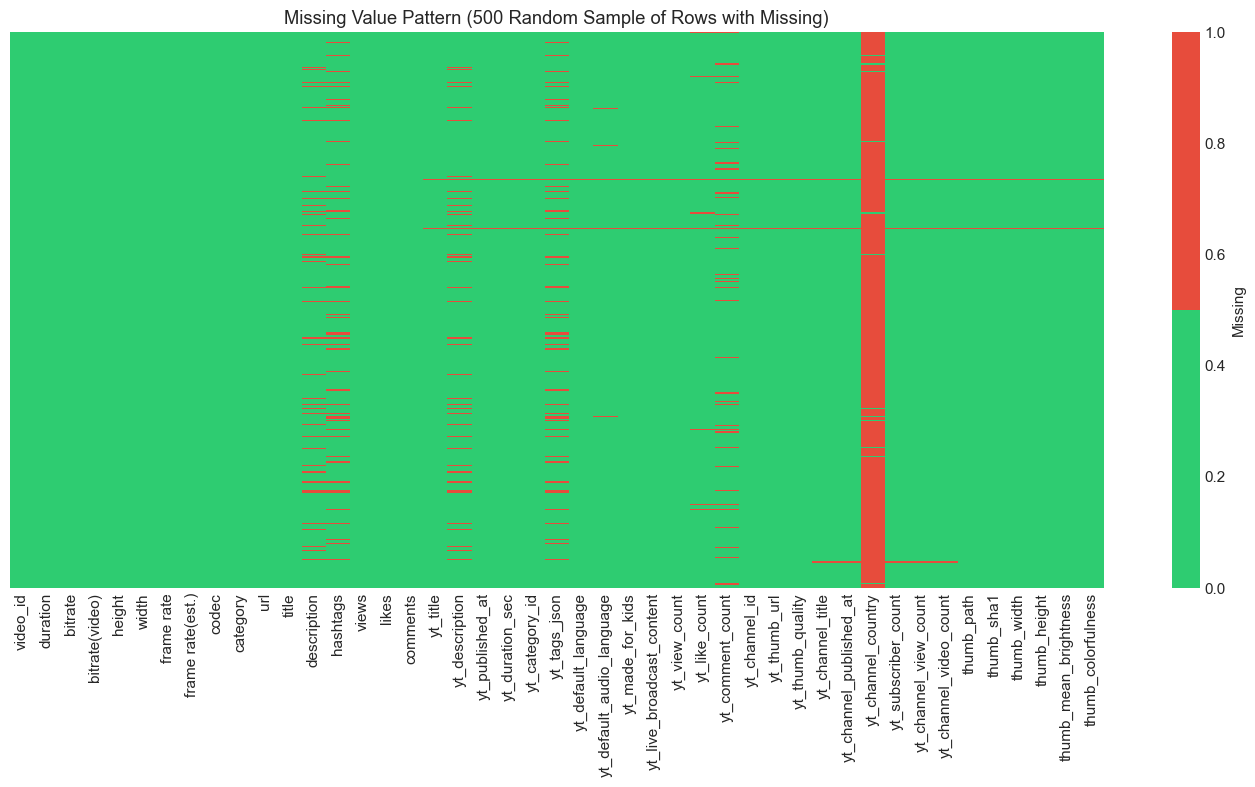

In [4]:
# Missing value heatmap (sample of rows with missing)
from matplotlib.colors import ListedColormap
miss_cmap = ListedColormap(['#2ecc71', '#e74c3c'])
rows_with_missing = df[df.isnull().any(axis=1)]
if len(rows_with_missing) > 0 and len(rows_with_missing) <= 500:
    plt.figure(figsize=(14, min(8, len(rows_with_missing) * 0.02)))
    sns.heatmap(rows_with_missing.isnull(), cbar_kws={'label': 'Missing'}, cmap=miss_cmap, yticklabels=False)
    plt.title('Missing Value Pattern (Rows with Any Missing)')
    plt.tight_layout()
    plt.show()
elif len(rows_with_missing) > 500:
    sample = rows_with_missing.sample(500, random_state=42)
    plt.figure(figsize=(14, 8))
    sns.heatmap(sample.isnull(), cbar_kws={'label': 'Missing'}, cmap=miss_cmap, yticklabels=False)
    plt.title('Missing Value Pattern (500 Random Sample of Rows with Missing)')
    plt.tight_layout()
    plt.show()

### 2.3 Duplicates & Data Integrity

In [5]:
# Duplicate check
dup_video_id = df['video_id'].duplicated().sum()
dup_rows = df.duplicated().sum()

print(f"Duplicate video_id: {dup_video_id}")
print(f"Fully duplicate rows: {dup_rows}")

if dup_video_id > 0:
    dup_ids = df[df['video_id'].duplicated(keep=False)]['video_id'].value_counts().head(5)
    print(f"\nSample duplicate video_ids:\n{dup_ids}")

Duplicate video_id: 0
Fully duplicate rows: 0


**Analysis.** The data quality assessment indicates a high degree of structural integrity and completeness in the enhanced dataset. No duplicate `video_id` entries or fully duplicated rows were detected, confirming that API joins and feature enrichment did not introduce record-level inconsistencies. Missing values are largely sparse and systematically distributed rather than random. Most engineered video- and channel-level features exhibit less than 1% missingness, supporting their inclusion in downstream exploratory and modeling analyses without aggressive imputation.

One notable exception is `yt_channel_country`, which is missing for approximately 88% of observations. This reflects platform-level reporting limitations rather than data collection error and suggests that geographic channel metadata should be excluded or treated as a low-coverage auxiliary feature. Moderate missingness in textual metadata fields (e.g., descriptions, tags, hashtags) is consistent with heterogeneous creator usage patterns and will require explicit handling depending on analytical objectives.

---
## 3. Descriptive Statistics

**Analysis.** The extended descriptive statistics provide essential context for variable scaling and model specification. Skewness and kurtosis indicate pronounced right-tailed distributions in engagement metrics (views, likes, comments), justifying log transformations for linear models. The interquartile range and full range reveal scale heterogeneity across variables; standardisation may be required for algorithms sensitive to feature magnitude. These statistics guide preprocessing decisions and inform expectations for residual diagnostics.

In [6]:
# --------------------------------
# Numeric columns (raw + engineered)
# --------------------------------
numeric_cols = [
    # Technical
    'duration',
    'bitrate',
    'bitrate(video)',
    'height',
    'width',
    'frame rate',
    'frame rate(est.)',

    # Engagement (raw counts)
    'views',
    'likes',
    'comments',
    'yt_view_count',
    'yt_like_count',
    'yt_comment_count',

    # Engagement rates (derived)
    'like_rate',
    'comment_rate',
    'engagement_score',

    # Creator-level
    'yt_subscriber_count',
    'yt_channel_video_count',

    # Temporal (derived)
    'video_age_days',
    'channel_age_days',

    # Thumbnail features
    'thumb_width',
    'thumb_height',
    'thumb_mean_brightness',
    'thumb_colorfulness'
]

# Keep only columns that actually exist
numeric_cols = [c for c in numeric_cols if c in df.columns]

# --------------------------------
# Extended statistics
# --------------------------------
stats = df[numeric_cols].describe().T

stats['skewness'] = df[numeric_cols].skew(numeric_only=True)
stats['kurtosis'] = df[numeric_cols].kurtosis(numeric_only=True)
stats['IQR'] = stats['75%'] - stats['25%']
stats['range'] = stats['max'] - stats['min']

stats = stats.round(2)
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR,range
duration,17589.0,241.55,493.03,1.00,51.00,135.00,268.00,2.584500e+04,16.96,601.82,217.00,2.584400e+04
bitrate,17589.0,1271.35,1375.36,0.00,437.00,743.00,1293.00,2.242100e+04,2.41,8.76,856.00,2.242100e+04
bitrate(video),17589.0,1150.42,1351.80,0.00,326.00,632.00,1184.00,2.222900e+04,2.45,9.16,858.00,2.222900e+04
height,17589.0,766.78,467.29,108.00,426.00,640.00,960.00,2.592000e+03,1.12,0.47,534.00,2.484000e+03
width,17589.0,504.59,262.73,88.00,320.00,480.00,720.00,1.944000e+03,1.30,2.31,400.00,1.856000e+03
frame rate,17589.0,26.47,6.04,3.75,25.00,29.97,29.97,5.908000e+01,-1.36,2.87,4.97,5.533000e+01
frame rate(est.),17589.0,9.47,13.25,0.00,0.00,0.00,25.00,3.000000e+01,0.75,-1.36,25.00,3.000000e+01
views,17589.0,68941.58,3537491.15,0.00,38.00,152.00,800.00,4.103849e+08,97.62,10655.63,762.00,4.103849e+08
likes,17589.0,208.86,8477.50,0.00,0.00,1.00,4.00,8.369810e+05,75.60,6440.81,4.00,8.369810e+05
comments,17589.0,12.90,225.84,0.00,0.00,0.00,1.00,1.663400e+04,49.28,3119.74,1.00,1.663400e+04


---
## 4. Categorical Variables - Deep Dive

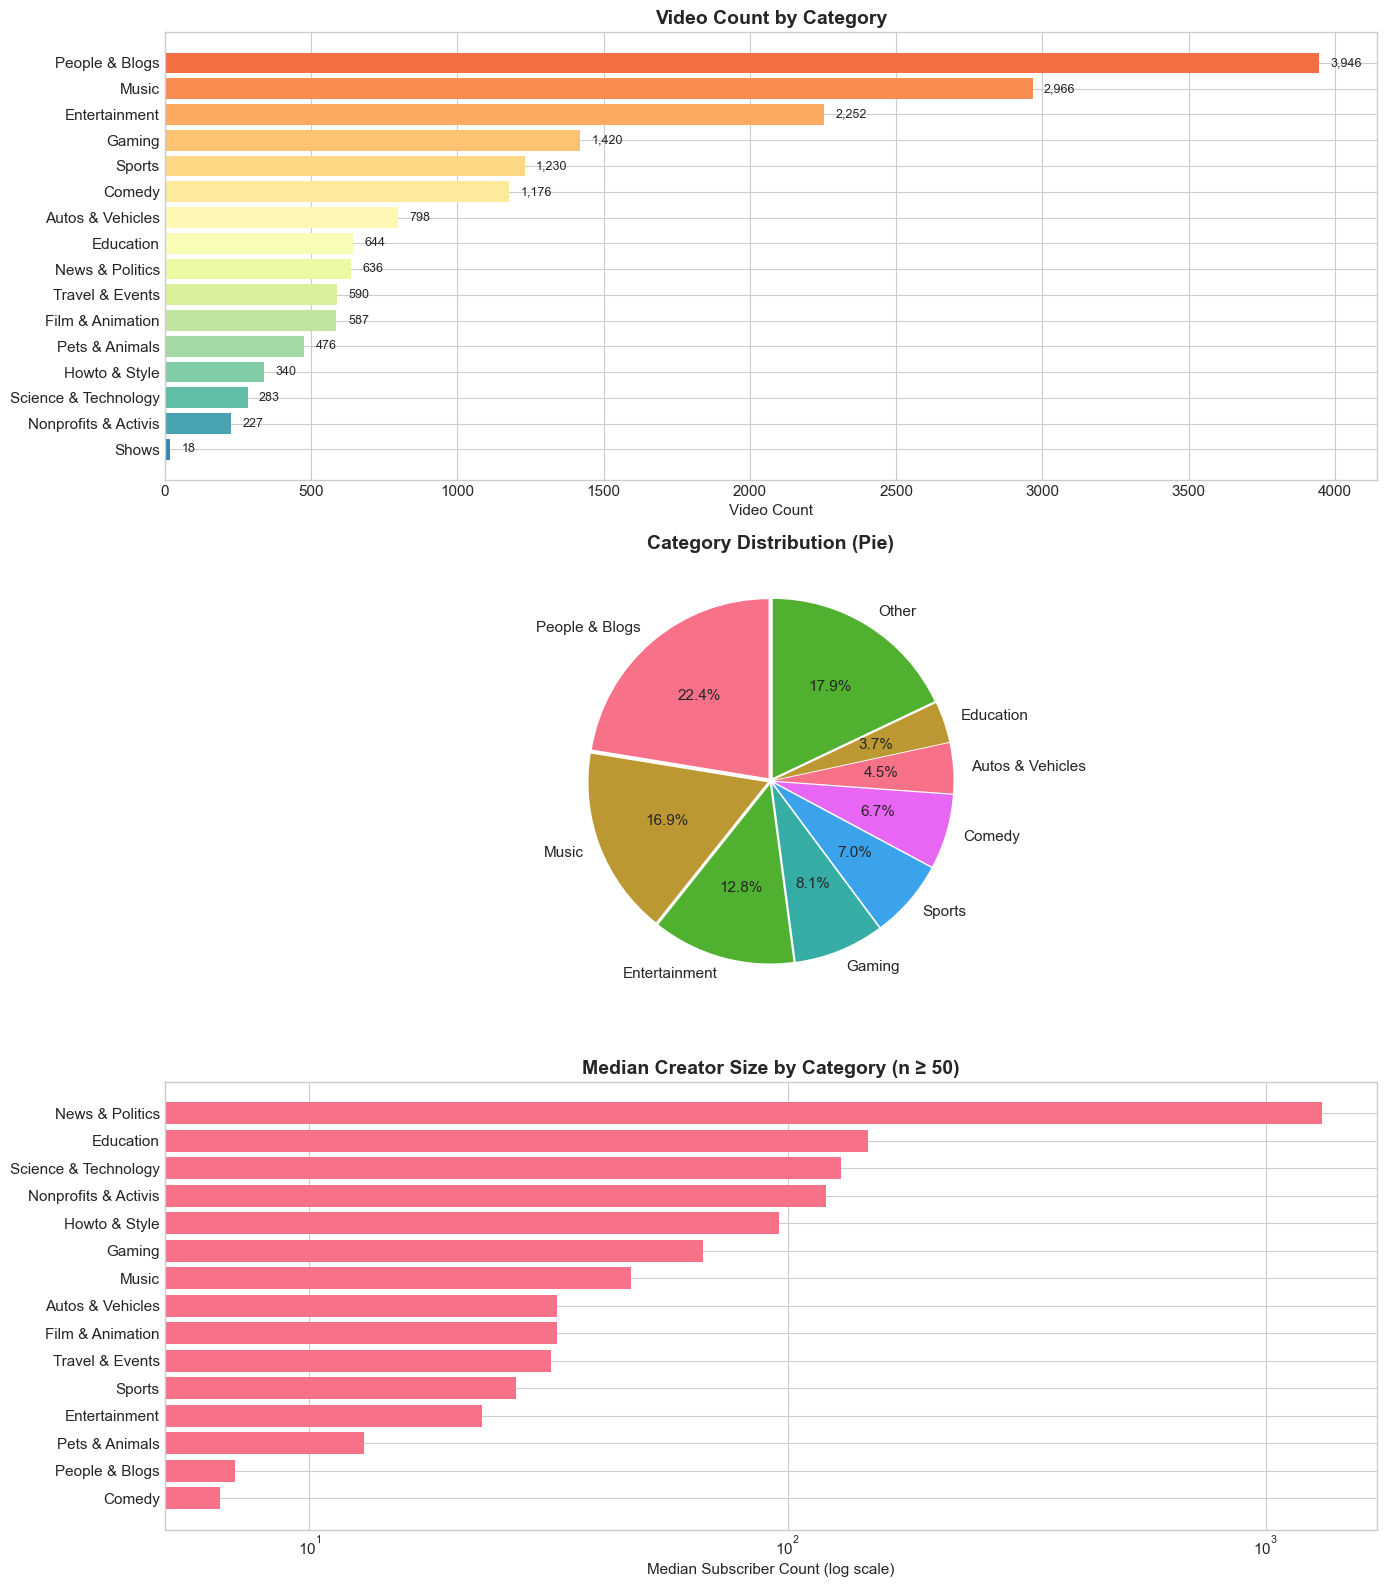

In [ ]:
# Optional: avoid categories with tiny sample sizes dominating comparisons
MIN_N = 50

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# ---------------------------
# 1) Category counts (barh)
# ---------------------------
cat_counts = df['category'].value_counts()
colors = plt.cm.Spectral(np.linspace(0.2, 0.9, len(cat_counts)))

bars = axes[0].barh(cat_counts.index, cat_counts.values, color=colors)
axes[0].set_xlabel('Video Count')
axes[0].set_title('Video Count by Category', fontsize=14, fontweight='bold')

for i, val in enumerate(cat_counts.values):
    axes[0].text(val + max(cat_counts.values)*0.01, i, f'{val:,}', va='center', fontsize=9)

axes[0].invert_yaxis()

# ---------------------------
# 2) Category distribution (pie)
# ---------------------------
top_n = 8
top_cats = cat_counts.head(top_n)
other_count = cat_counts.iloc[top_n:].sum() if len(cat_counts) > top_n else 0
pie_data = list(top_cats.values) + ([other_count] if other_count > 0 else [])
pie_labels = list(top_cats.index) + (['Other'] if other_count > 0 else [])

axes[1].pie(
    pie_data,
    labels=pie_labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02]*len(pie_data)
)
axes[1].set_title('Category Distribution (Pie)', fontsize=14, fontweight='bold')

# ---------------------------
# 3) NEW: Median subscribers by category (log scale)
# ---------------------------
if 'yt_subscriber_count' in df.columns:
    subs_df = df[['category', 'yt_subscriber_count']].dropna()

    # filter tiny categories
    valid_cats = subs_df['category'].value_counts()
    valid_cats = valid_cats[valid_cats >= MIN_N].index
    subs_df = subs_df[subs_df['category'].isin(valid_cats)]

    med_subs = subs_df.groupby('category')['yt_subscriber_count'].median().sort_values(ascending=False)

    axes[2].barh(med_subs.index, med_subs.values)
    axes[2].invert_yaxis()
    axes[2].set_xscale('log')  # critical because subs are insanely skewed
    axes[2].set_xlabel('Median Subscriber Count (log scale)')
    axes[2].set_title(f'Median Creator Size by Category (n ≥ {MIN_N})', fontsize=14, fontweight='bold')
else:
    axes[2].axis("off")
    axes[2].text(0.5, 0.5, "yt_subscriber_count not found in df", ha='center', va='center')

plt.tight_layout()
plt.show()

**Analysis.** Category distributions reveal a highly uneven content ecology, with People & Blogs, Music, and Entertainment accounting for a substantial share of the dataset, while several categories remain sparsely represented. This imbalance suggests that category effects must be interpreted cautiously, and that pooling or regularisation may be necessary for underrepresented domains. Beyond volume, substantial heterogeneity emerges in creator size across categories: median subscriber counts differ by more than an order of magnitude, with News & Politics, Education, and Science & Technology dominated by larger channels, while People & Blogs, Comedy, and Pets & Animals are largely composed of smaller creators. This pattern indicates that category is closely intertwined with creator social capital, implying that observed engagement differences may reflect structural channel advantages rather than content attributes alone. Consequently, downstream modelling should explicitly control for subscriber count and consider category–creator interactions, as category effects may partially proxy for underlying audience scale rather than intrinsic virality mechanisms.

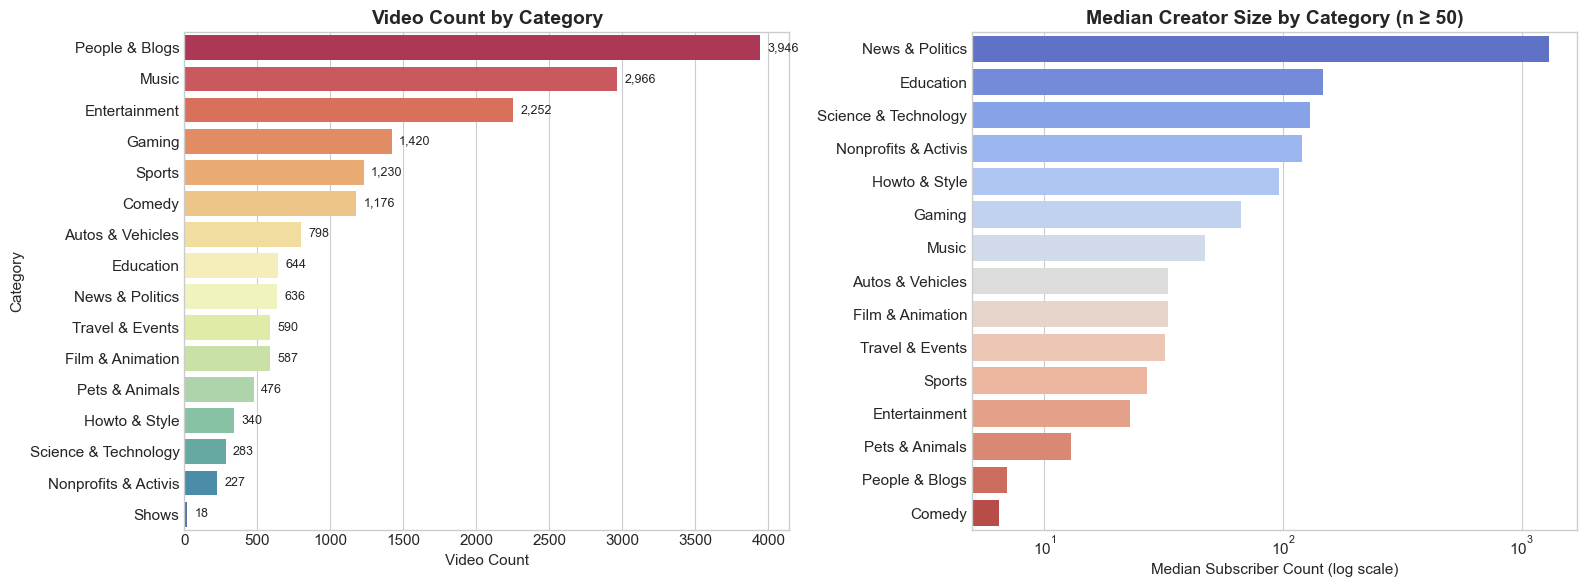

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------
# Left: Video count by category
# -----------------------------
cat_counts = df['category'].value_counts()
sns.barplot(
    y=cat_counts.index,
    x=cat_counts.values,
    ax=axes[0],
    palette='Spectral'
)

axes[0].set_title('Video Count by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Video Count')
axes[0].set_ylabel('Category')

for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# -----------------------------
# Right: Median creator size by category
# (only categories with enough data)
# -----------------------------
creator_stats = (
    df.dropna(subset=['yt_subscriber_count'])
      .groupby('category')
      .agg(
          median_subs=('yt_subscriber_count', 'median'),
          n_videos=('video_id', 'count')
      )
      .query('n_videos >= 50')        # stability filter
      .sort_values('median_subs', ascending=False)
)

sns.barplot(
    y=creator_stats.index,
    x=creator_stats['median_subs'],
    ax=axes[1],
    palette='coolwarm'
)

axes[1].set_xscale('log')
axes[1].set_title('Median Creator Size by Category (n ≥ 50)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Median Subscriber Count (log scale)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 5. Numeric Distributions - Multi-View

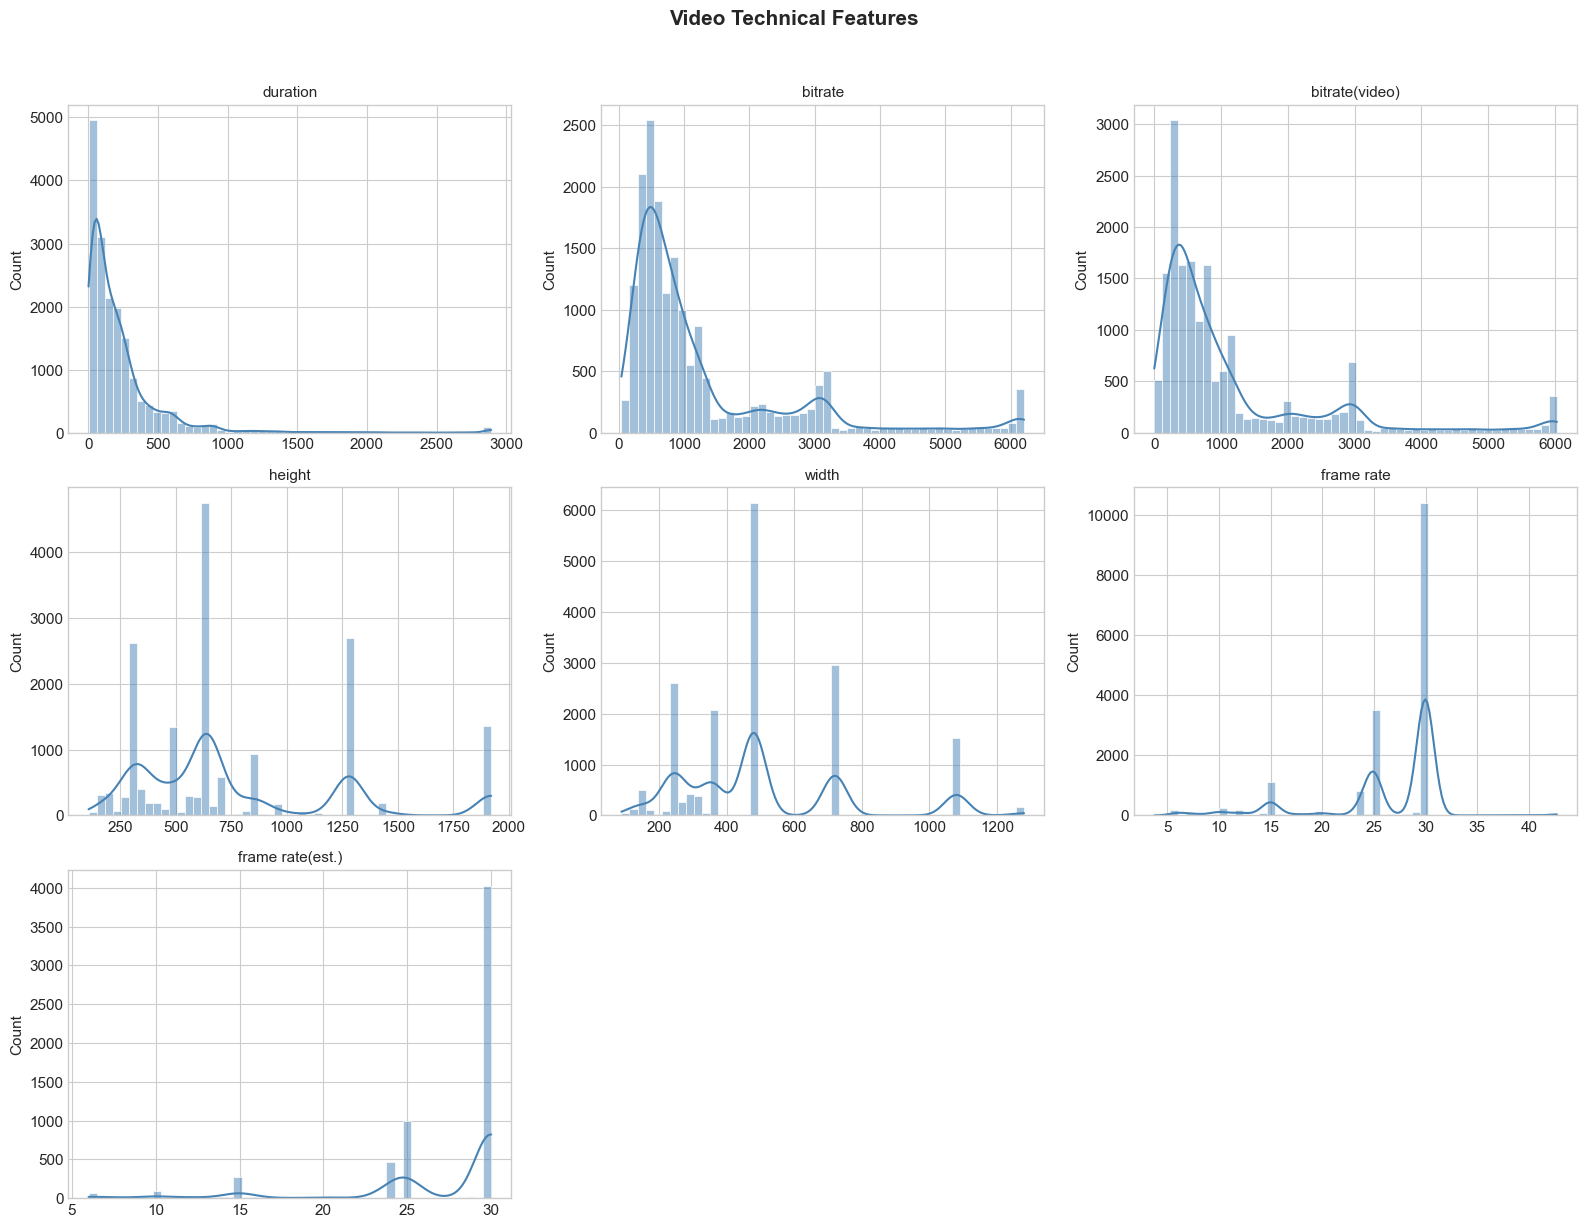

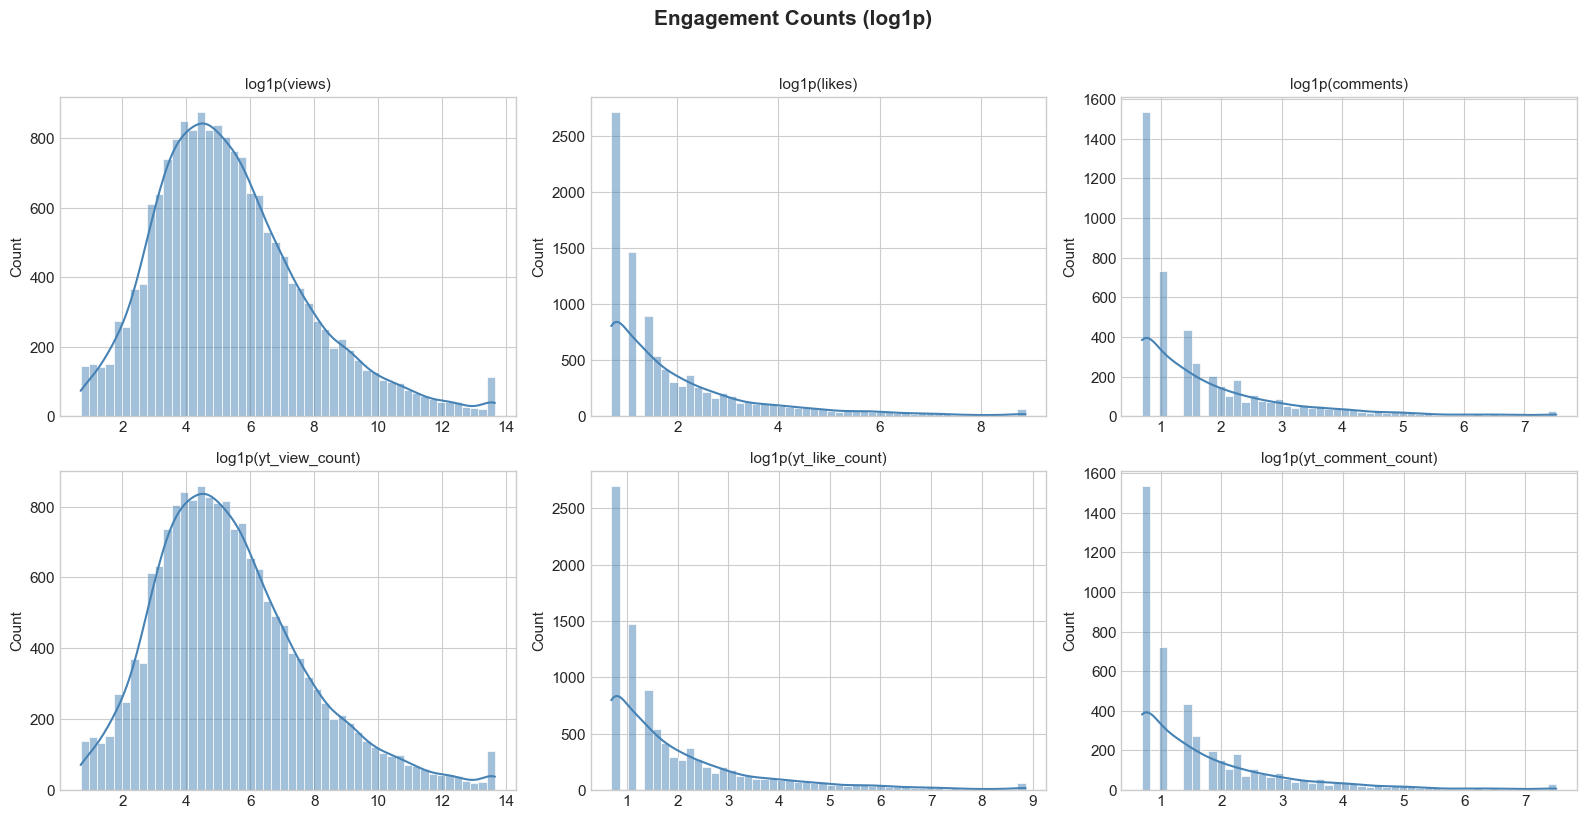

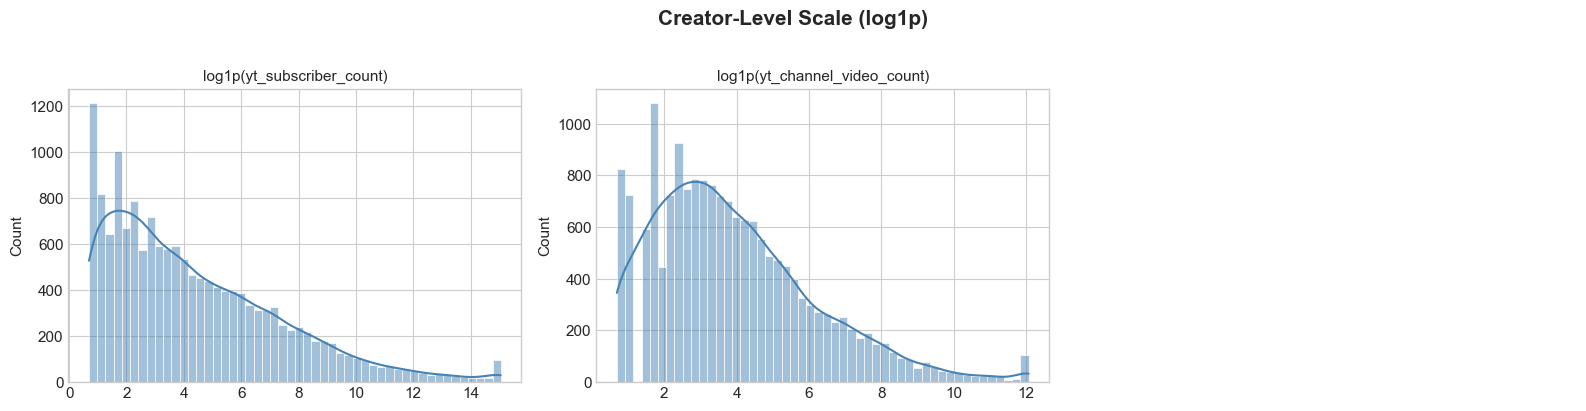

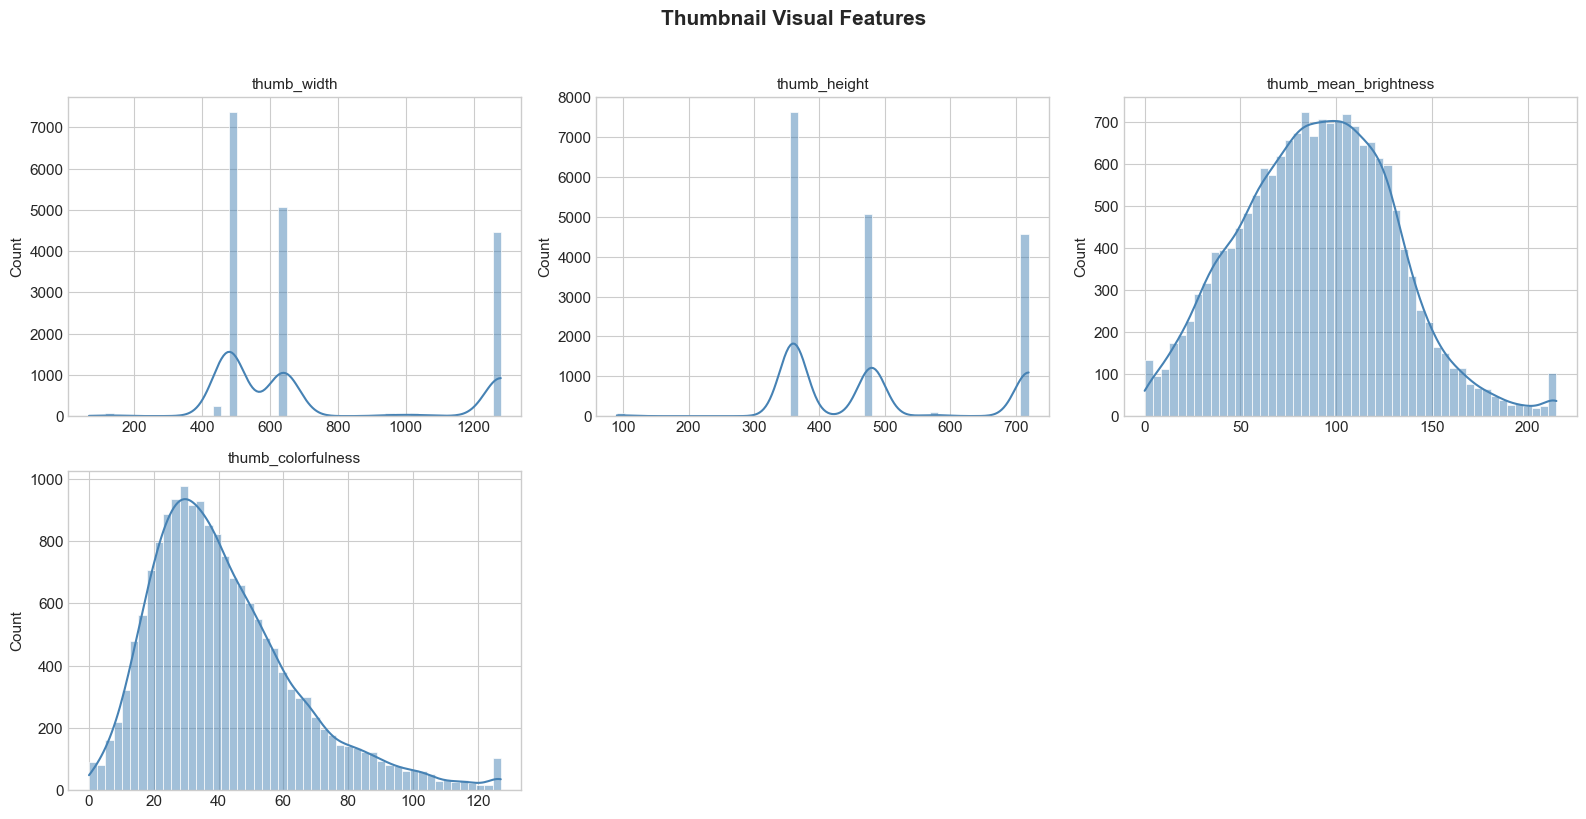

In [11]:
tech_cols = [
    'duration', 'bitrate', 'bitrate(video)',
    'height', 'width',
    'frame rate', 'frame rate(est.)'
]

engagement_counts = [
    'views', 'likes', 'comments',
    'yt_view_count', 'yt_like_count', 'yt_comment_count'
]

creator_cols = [
    'yt_subscriber_count',
    'yt_channel_video_count'
]

thumbnail_cols = [
    'thumb_width', 'thumb_height',
    'thumb_mean_brightness',
    'thumb_colorfulness'
]

numeric_groups = {
    "Video Technical Features": tech_cols,
    "Engagement Counts (log1p)": engagement_counts,
    "Creator-Level Scale (log1p)": creator_cols,
    "Thumbnail Visual Features": thumbnail_cols
}

for title, cols in numeric_groups.items():
    cols = [c for c in cols if c in df.columns]
    if not cols:
        continue

    n_cols = 3
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        data = df[col].replace(0, np.nan).dropna()

        # log-transform where appropriate
        if col in engagement_counts or col in creator_cols:
            data = np.log1p(data)
            label = f'log1p({col})'
        else:
            label = col

        # optional cap for extreme tails
        upper = data.quantile(0.995)
        data = data.clip(upper=upper)

        sns.histplot(
            data,
            kde=True,
            bins=50,
            ax=ax,
            color='steelblue',
            edgecolor='white'
        )
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('')
        ax.set_ylabel('Count')

    # turn off unused axes
    for ax in axes[len(cols):]:
        ax.axis('off')

    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

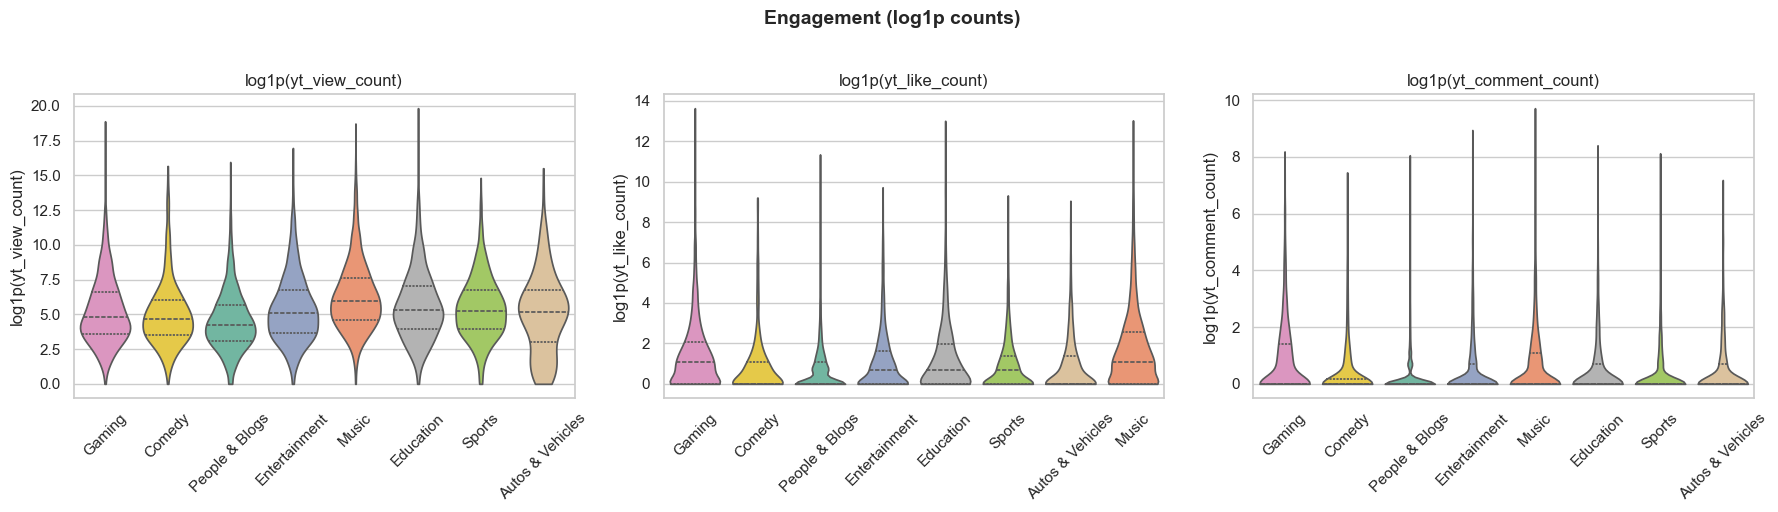

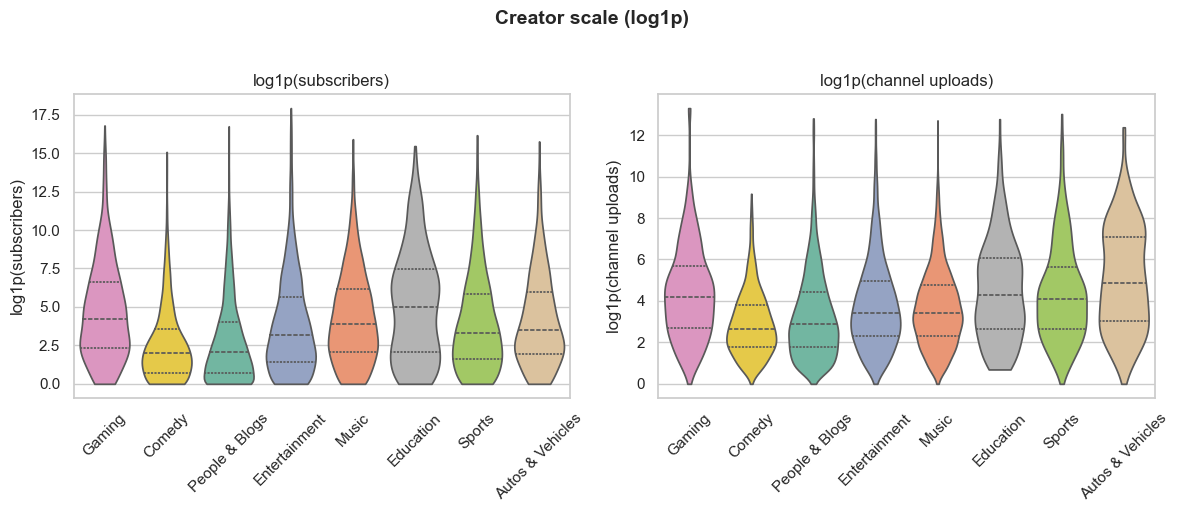

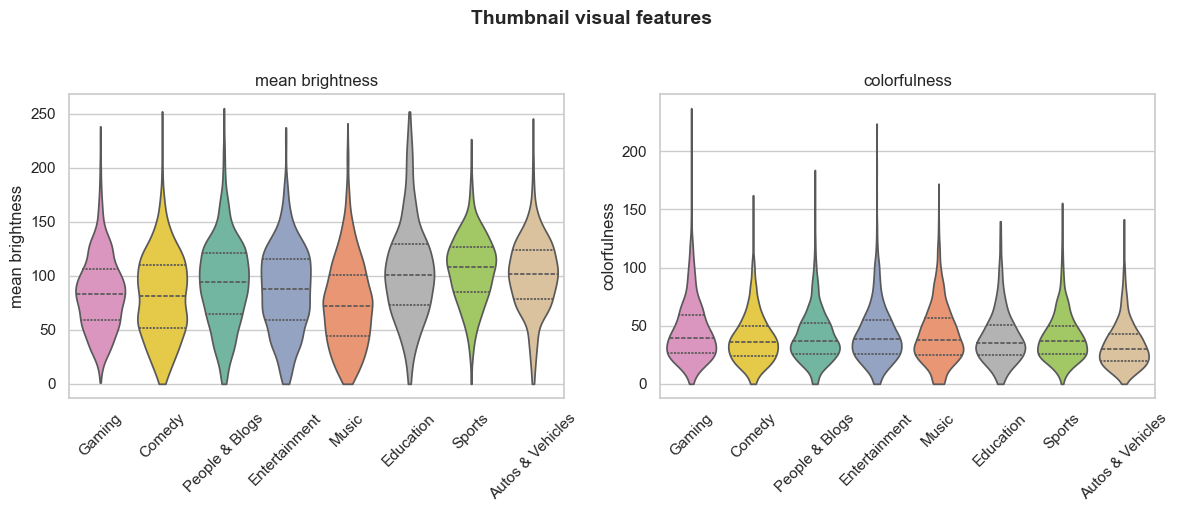

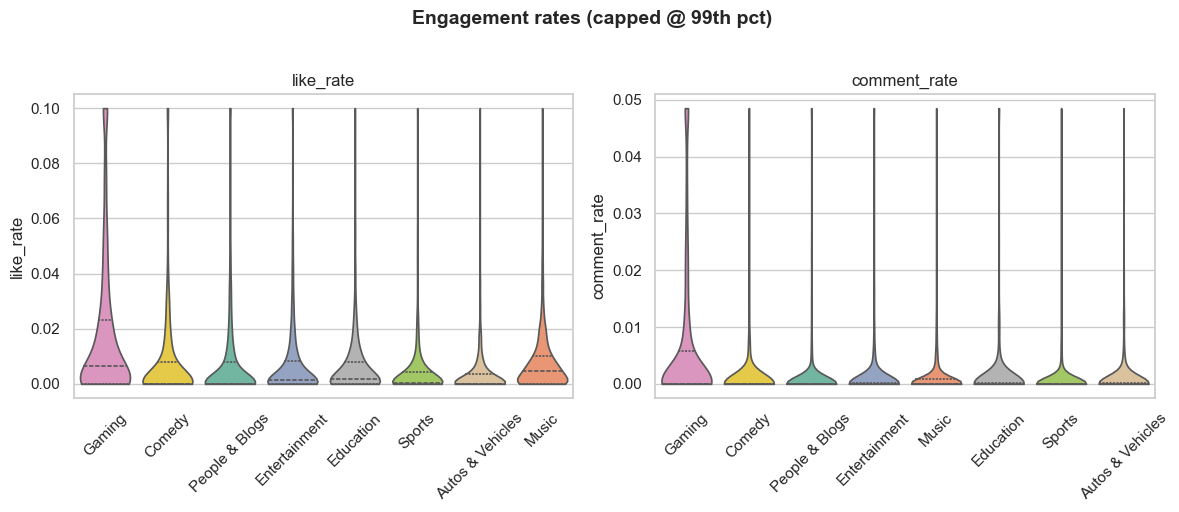

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Prep: pick top categories
# ----------------------------
TOP_N = 8
top_categories = df['category'].value_counts().head(TOP_N).index.tolist()
df_top = df[df['category'].isin(top_categories)].copy()

# Optional: drop rows missing category
df_top = df_top.dropna(subset=["category"])

# ✅ Stable color palette for categories (consistent across ALL plots)
palette = sns.color_palette("Set2", n_colors=len(top_categories))
category_palette = dict(zip(top_categories, palette))

# ----------------------------
# Derived metrics (safe)
# ----------------------------
# Log transforms (avoid log(0) issues with log1p)
for col in ["views", "likes", "comments",
            "yt_view_count", "yt_like_count", "yt_comment_count",
            "yt_subscriber_count", "yt_channel_video_count",
            "thumb_mean_brightness", "thumb_colorfulness"]:
    if col in df_top.columns:
        df_top[f"log1p_{col}"] = np.log1p(pd.to_numeric(df_top[col], errors="coerce"))

# Use yt_* counts when available, fall back to original
views_base = "yt_view_count" if "yt_view_count" in df_top.columns else "views"
likes_base = "yt_like_count" if "yt_like_count" in df_top.columns else "likes"
comments_base = "yt_comment_count" if "yt_comment_count" in df_top.columns else "comments"

df_top[views_base] = pd.to_numeric(df_top[views_base], errors="coerce")
df_top[likes_base] = pd.to_numeric(df_top[likes_base], errors="coerce")
df_top[comments_base] = pd.to_numeric(df_top[comments_base], errors="coerce")

# Engagement rates
df_top["like_rate"] = df_top[likes_base] / df_top[views_base].replace(0, np.nan)
df_top["comment_rate"] = df_top[comments_base] / df_top[views_base].replace(0, np.nan)

# Cap extreme rates so violins aren’t dominated by outliers
df_top["like_rate_cap"] = df_top["like_rate"].clip(upper=df_top["like_rate"].quantile(0.99))
df_top["comment_rate_cap"] = df_top["comment_rate"].clip(upper=df_top["comment_rate"].quantile(0.99))

# ----------------------------
# Plot sets (grouped)
# ----------------------------
plot_groups = [
    {
        "title": "Engagement (log1p counts)",
        "cols": [
            ("log1p_"+views_base, f"log1p({views_base})"),
            ("log1p_"+likes_base, f"log1p({likes_base})"),
            ("log1p_"+comments_base, f"log1p({comments_base})"),
        ],
    },
    {
        "title": "Creator scale (log1p)",
        "cols": [
            ("log1p_yt_subscriber_count", "log1p(subscribers)"),
            ("log1p_yt_channel_video_count", "log1p(channel uploads)"),
        ],
    },
    {
        "title": "Thumbnail visual features",
        "cols": [
            ("thumb_mean_brightness", "mean brightness"),
            ("thumb_colorfulness", "colorfulness"),
        ],
    },
    {
        "title": "Engagement rates (capped @ 99th pct)",
        "cols": [
            ("like_rate_cap", "like_rate"),
            ("comment_rate_cap", "comment_rate"),
        ],
    },
]

# Filter out any plots whose columns don't exist
filtered_groups = []
for g in plot_groups:
    available = [(c, lab) for (c, lab) in g["cols"] if c in df_top.columns]
    if available:
        g2 = dict(g)
        g2["cols"] = available
        filtered_groups.append(g2)

# ----------------------------
# Draw plots
# ----------------------------
sns.set(style="whitegrid")

for g in filtered_groups:
    n = len(g["cols"])
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, g["cols"]):
        plot_df = df_top.dropna(subset=[col]).copy()

        sns.violinplot(
            data=plot_df,
            x="category",
            y=col,
            ax=ax,
            palette=category_palette,  
            inner="quartile",     
            cut=0                      
        )

        ax.set_title(label)
        ax.set_xlabel("")
        ax.set_ylabel(label)
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle(g["title"], fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

**Analysis.** 

Across engagement, creator, technical, and visual features, the data exhibit strong heavy-tailed structure and pronounced heterogeneity. Log-transformed views, likes, comments, and subscriber counts remain right-skewed but substantially more regular, consistent with multiplicative growth processes typical of platform dynamics. Violin plots by category reveal systematic differences not only in engagement volume but also in engagement rates, creator scale, thumbnail characteristics, and upload behavior, indicating that content type mediates both reach and interaction intensity. High-reach categories often show lower median engagement rates, reinforcing the distinction between scale and depth of engagement. Technical attributes such as duration, bitrate, resolution, and frame rate display multimodality, reflecting a mixture of professionalized production pipelines and casual user-generated content. Thumbnail brightness and colorfulness further differentiate categories, suggesting that visual presentation strategies vary alongside content semantics. Outlier analysis confirms that extreme values are concentrated in engagement and scale variables rather than temporal features, supporting robust transformations and capped rates.

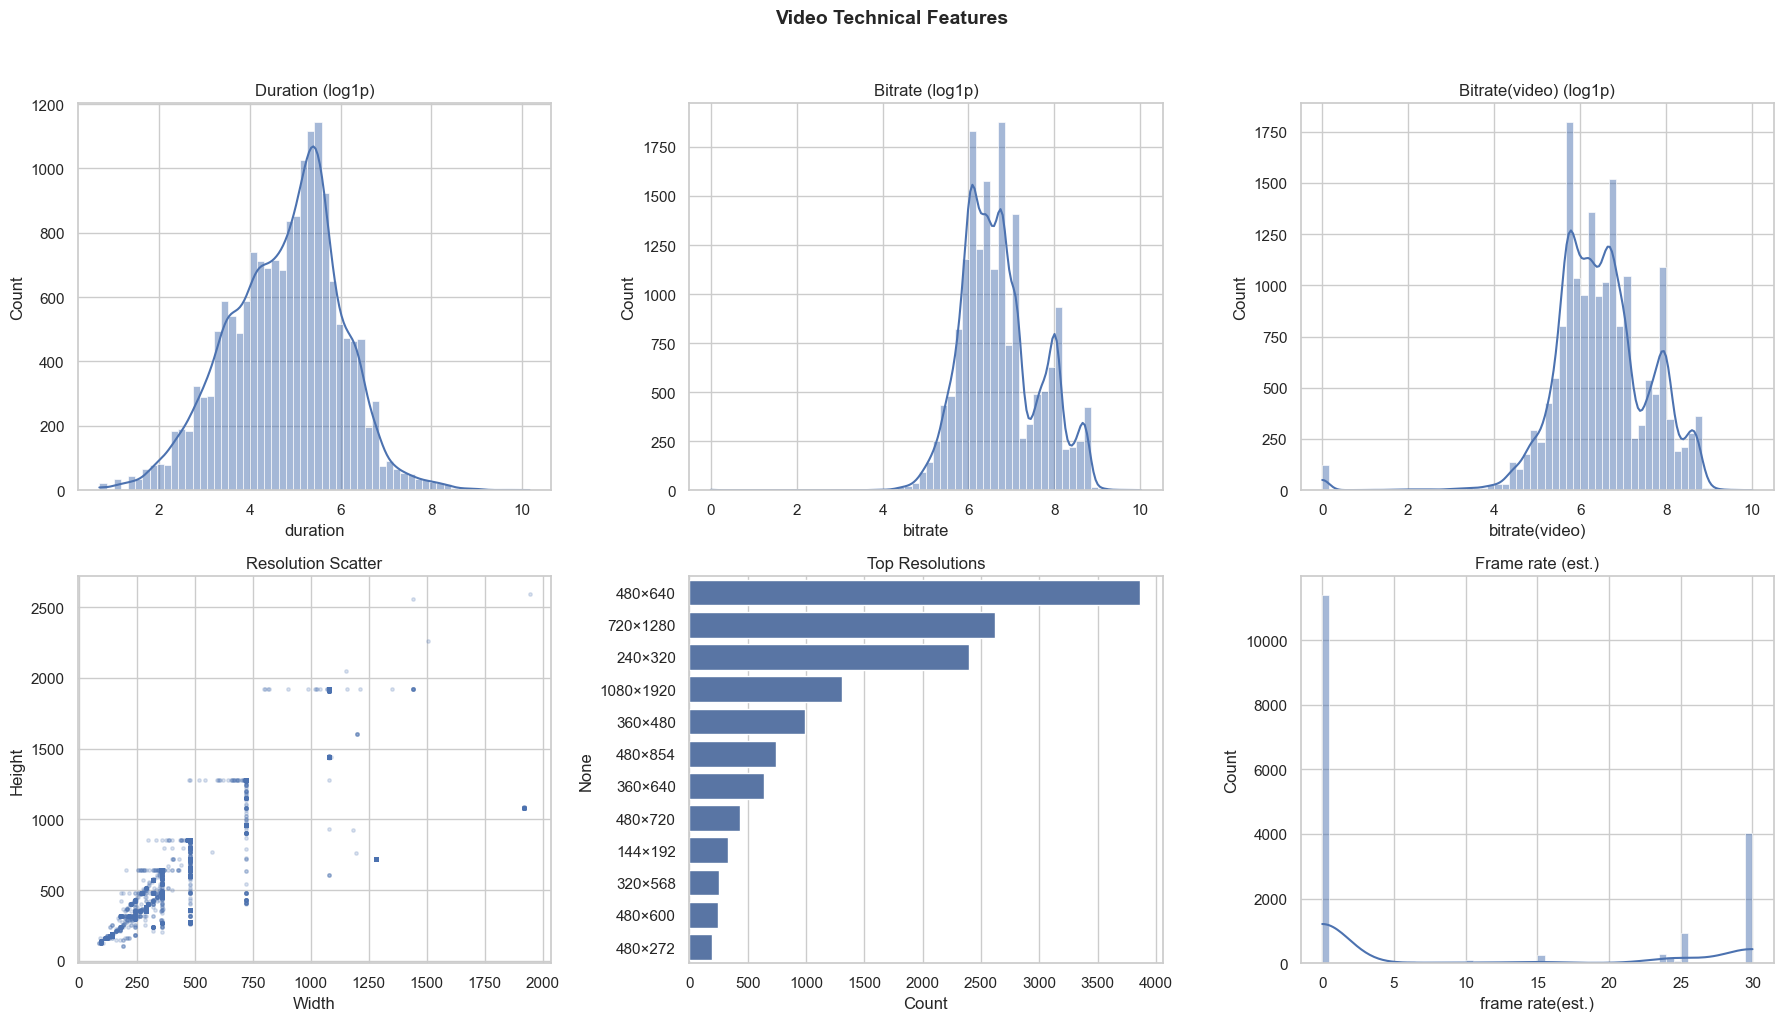

In [16]:
# ----------------------------
# Video technical attributes (enhanced)
# ----------------------------
sns.set(style="whitegrid")

# Helper: safe numeric conversion
def _num(s):
    return pd.to_numeric(s, errors="coerce")

# Columns we want if present
dur_col = "duration" if "duration" in df.columns else None
bit_col = "bitrate" if "bitrate" in df.columns else None
bitv_col = "bitrate(video)" if "bitrate(video)" in df.columns else None
fr_col = "frame rate" if "frame rate" in df.columns else None
fr_est_col = "frame rate(est.)" if "frame rate(est.)" in df.columns else None

w_col = "width" if "width" in df.columns else None
h_col = "height" if "height" in df.columns else None

# Layout: 2 rows x 3 cols
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) Duration (log1p)
if dur_col:
    sns.histplot(np.log1p(_num(df[dur_col]).dropna()), kde=True, ax=axes[0, 0], bins=60)
    axes[0, 0].set_title("Duration (log1p)")
else:
    axes[0, 0].axis("off")

# 2) Bitrate (log1p)
if bit_col:
    sns.histplot(np.log1p(_num(df[bit_col]).dropna()), kde=True, ax=axes[0, 1], bins=60)
    axes[0, 1].set_title("Bitrate (log1p)")
else:
    axes[0, 1].axis("off")

# 3) Video bitrate (log1p) if available; otherwise frame rate
if bitv_col:
    sns.histplot(np.log1p(_num(df[bitv_col]).dropna()), kde=True, ax=axes[0, 2], bins=60)
    axes[0, 2].set_title("Bitrate(video) (log1p)")
elif fr_col:
    sns.histplot(_num(df[fr_col]).dropna(), kde=True, ax=axes[0, 2], bins=60)
    axes[0, 2].set_title("Frame rate")
else:
    axes[0, 2].axis("off")

# 4) Resolution scatter
if w_col and h_col:
    ww = _num(df[w_col])
    hh = _num(df[h_col])
    m = ww.notna() & hh.notna()
    axes[1, 0].scatter(ww[m], hh[m], alpha=0.2, s=6)
    axes[1, 0].set_xlabel("Width")
    axes[1, 0].set_ylabel("Height")
    axes[1, 0].set_title("Resolution Scatter")
else:
    axes[1, 0].axis("off")

# 5) Top resolutions
if w_col and h_col:
    res_label = _num(df[w_col]).astype("Int64").astype(str) + "×" + _num(df[h_col]).astype("Int64").astype(str)
    res_counts = res_label.replace("<NA>×<NA>", np.nan).dropna().value_counts().head(12)

    sns.barplot(y=res_counts.index, x=res_counts.values, ax=axes[1, 1])
    axes[1, 1].set_title("Top Resolutions")
    axes[1, 1].set_xlabel("Count")
else:
    axes[1, 1].axis("off")

# 6) Frame rate (est.) distribution if available; otherwise hide
if fr_est_col:
    sns.histplot(_num(df[fr_est_col]).dropna(), kde=True, ax=axes[1, 2], bins=60)
    axes[1, 2].set_title("Frame rate (est.)")
elif fr_col and not bitv_col:
    # If we used frame rate in top row already, just hide this
    axes[1, 2].axis("off")
elif fr_col:
    sns.histplot(_num(df[fr_col]).dropna(), kde=True, ax=axes[1, 2], bins=60)
    axes[1, 2].set_title("Frame rate")
else:
    axes[1, 2].axis("off")

plt.suptitle("Video Technical Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Derived Features & Engagement Metrics

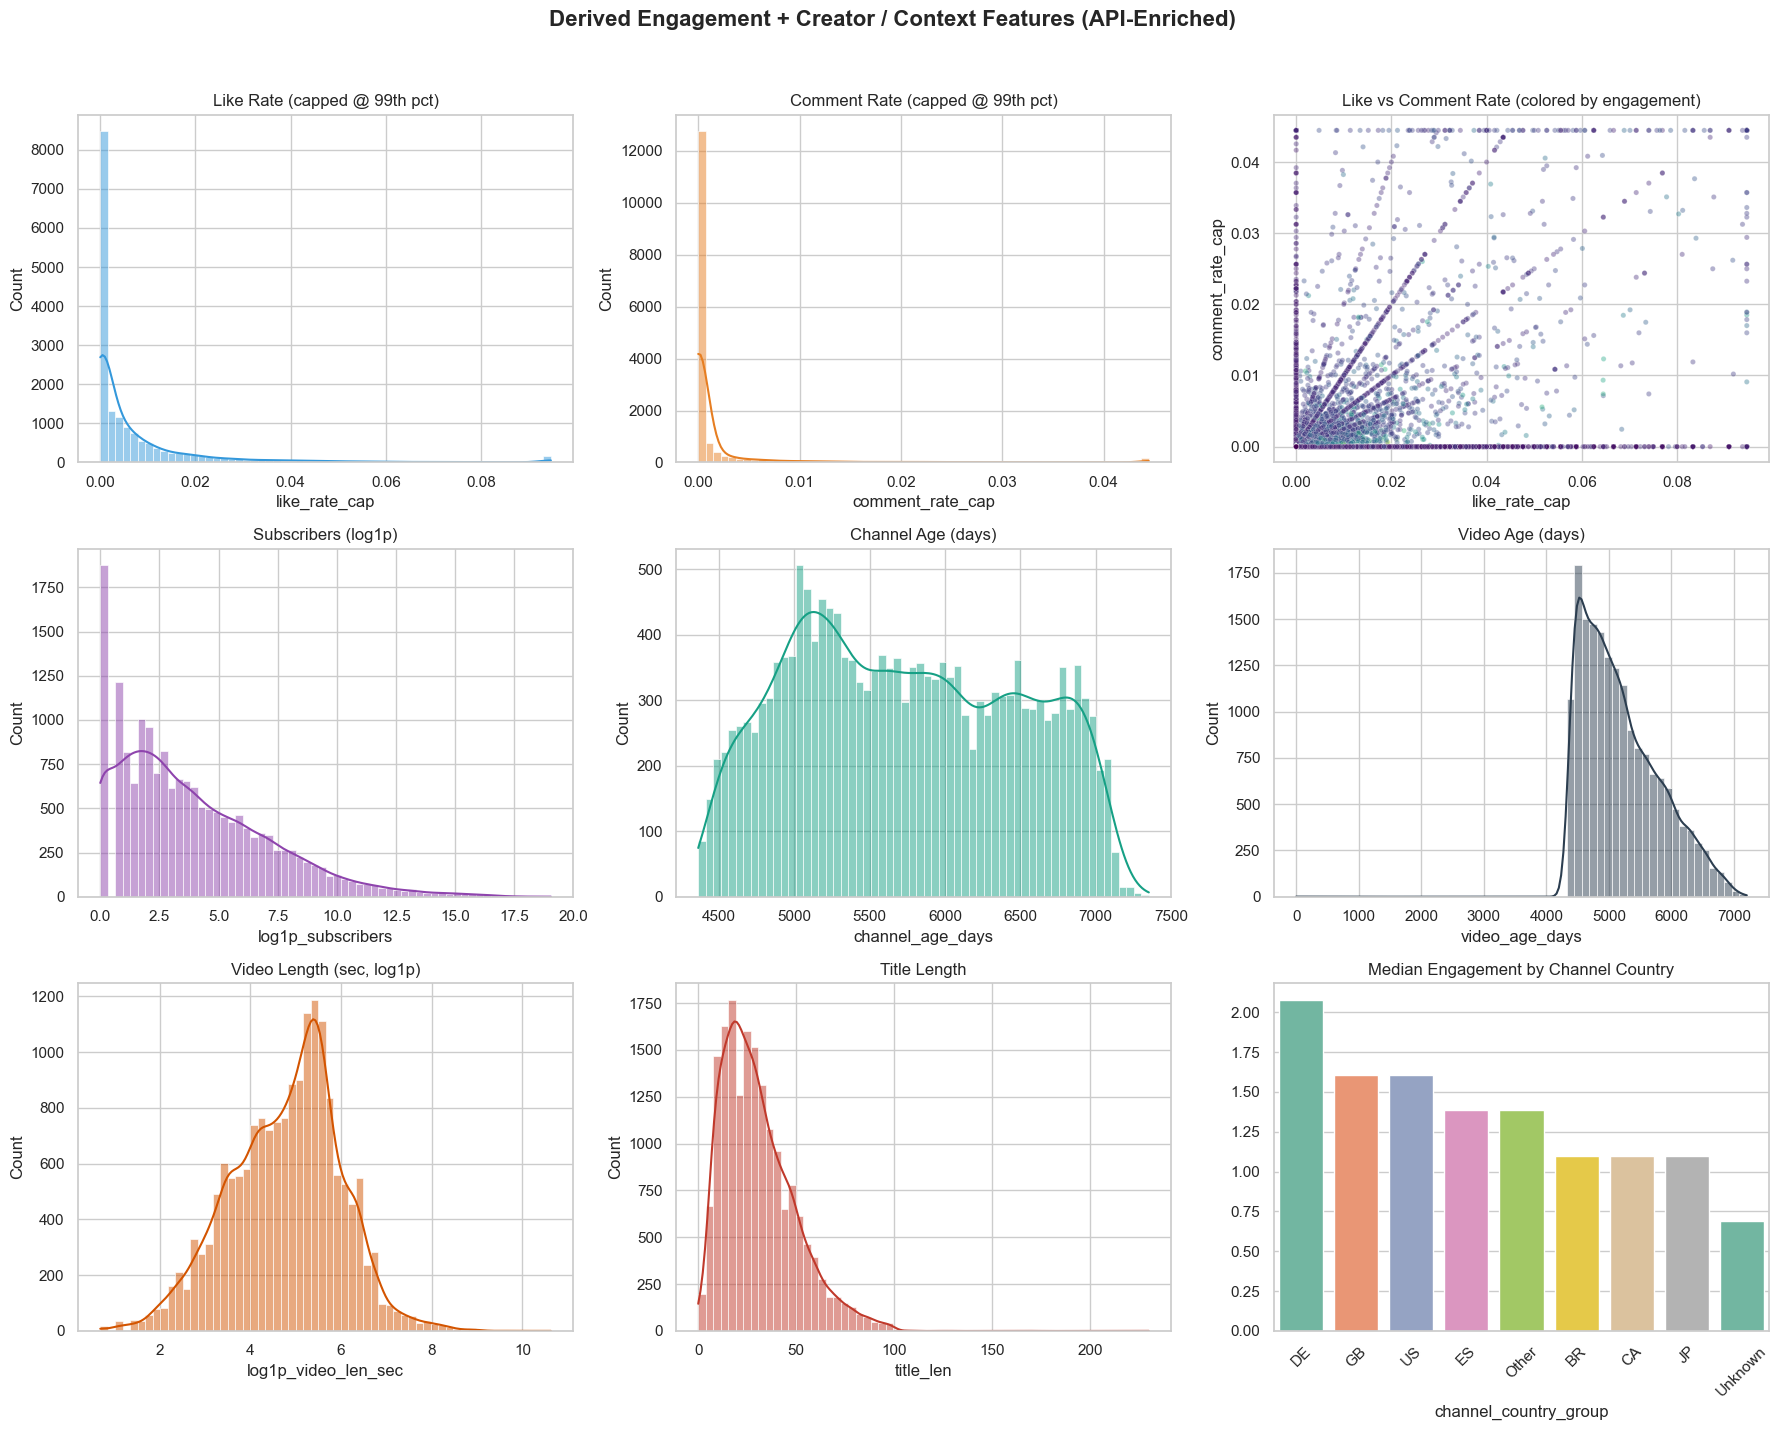

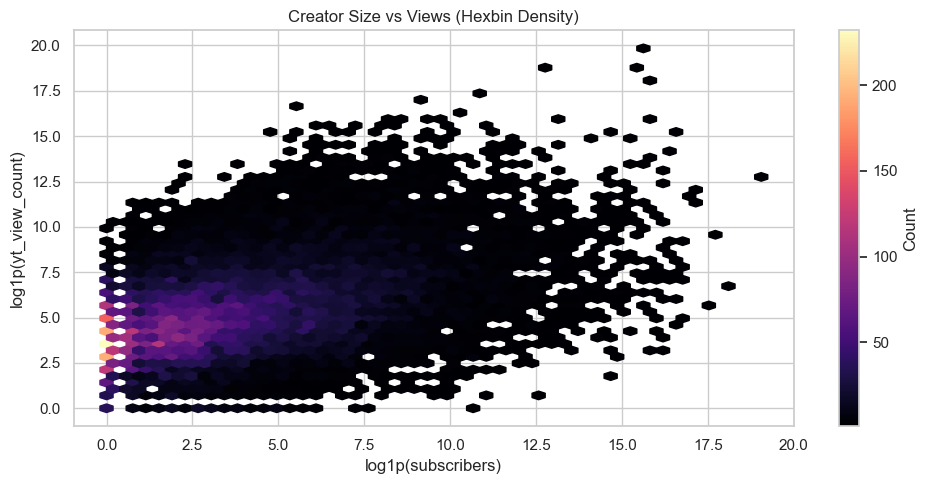

In [19]:
sns.set_theme(style="whitegrid", context="notebook")

df_eng = df.copy()

# ----------------------------
# Helper: prefer yt_* counts when available
# ----------------------------
def pick_col(primary, fallback):
    return primary if primary in df_eng.columns else fallback

views_col = pick_col("yt_view_count", "views")
likes_col = pick_col("yt_like_count", "likes")
comments_col = pick_col("yt_comment_count", "comments")

# Ensure numeric
for c in [
    views_col, likes_col, comments_col,
    "yt_subscriber_count", "yt_channel_video_count",
    "yt_channel_view_count", "yt_duration_sec"
]:
    if c in df_eng.columns:
        df_eng[c] = pd.to_numeric(df_eng[c], errors="coerce")

# ----------------------------
# Time features
# ----------------------------
df_eng["yt_published_at_dt"] = pd.to_datetime(
    df_eng.get("yt_published_at"), errors="coerce", utc=True
)
df_eng["yt_channel_published_at_dt"] = pd.to_datetime(
    df_eng.get("yt_channel_published_at"), errors="coerce", utc=True
)

ref_time = df_eng["yt_published_at_dt"].max()
if pd.isna(ref_time):
    ref_time = pd.Timestamp.utcnow()

df_eng["video_age_days"] = (ref_time - df_eng["yt_published_at_dt"]).dt.days
df_eng["channel_age_days"] = (ref_time - df_eng["yt_channel_published_at_dt"]).dt.days

# ----------------------------
# Engagement features
# ----------------------------
df_eng["like_rate"] = df_eng[likes_col] / df_eng[views_col].replace(0, np.nan)
df_eng["comment_rate"] = df_eng[comments_col] / df_eng[views_col].replace(0, np.nan)

df_eng["like_rate_cap"] = df_eng["like_rate"].clip(
    upper=df_eng["like_rate"].quantile(0.99)
)
df_eng["comment_rate_cap"] = df_eng["comment_rate"].clip(
    upper=df_eng["comment_rate"].quantile(0.99)
)

df_eng["engagement_score"] = np.log1p(
    df_eng[likes_col].fillna(0) + 2 * df_eng[comments_col].fillna(0)
)

# ----------------------------
# Creator + content features
# ----------------------------
df_eng["log1p_subscribers"] = np.log1p(df_eng.get("yt_subscriber_count"))
df_eng["log1p_channel_uploads"] = np.log1p(df_eng.get("yt_channel_video_count"))
df_eng["log1p_video_len_sec"] = np.log1p(df_eng.get("yt_duration_sec"))

title_src = "yt_title" if "yt_title" in df_eng.columns else "title"
df_eng["title_len"] = df_eng[title_src].fillna("").astype(str).str.len()

# Country grouping
if "yt_channel_country" in df_eng.columns:
    top_ctry = (
        df_eng["yt_channel_country"]
        .fillna("Unknown")
        .value_counts()
        .head(8)
        .index
    )
    df_eng["channel_country_group"] = df_eng["yt_channel_country"].fillna("Unknown")
    df_eng.loc[~df_eng["channel_country_group"].isin(top_ctry), "channel_country_group"] = "Other"
else:
    df_eng["channel_country_group"] = "Unknown"

# ============================================================
# PLOTS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# ---------- Row 1: Engagement rates ----------
sns.histplot(
    df_eng["like_rate_cap"].dropna(),
    bins=60, kde=True, ax=axes[0, 0],
    color="#3498db"
)
axes[0, 0].set_title("Like Rate (capped @ 99th pct)")

sns.histplot(
    df_eng["comment_rate_cap"].dropna(),
    bins=60, kde=True, ax=axes[0, 1],
    color="#e67e22"
)
axes[0, 1].set_title("Comment Rate (capped @ 99th pct)")

sns.scatterplot(
    data=df_eng,
    x="like_rate_cap",
    y="comment_rate_cap",
    hue="engagement_score",
    palette="viridis",
    alpha=0.4,
    s=14,
    ax=axes[0, 2],
    legend=False
)
axes[0, 2].set_title("Like vs Comment Rate (colored by engagement)")

# ---------- Row 2: Creator scale + age ----------
sns.histplot(
    df_eng["log1p_subscribers"].dropna(),
    bins=60, kde=True, ax=axes[1, 0],
    color="#8e44ad"
)
axes[1, 0].set_title("Subscribers (log1p)")

sns.histplot(
    df_eng["channel_age_days"].dropna(),
    bins=60, kde=True, ax=axes[1, 1],
    color="#16a085"
)
axes[1, 1].set_title("Channel Age (days)")

sns.histplot(
    df_eng["video_age_days"].dropna(),
    bins=60, kde=True, ax=axes[1, 2],
    color="#2c3e50"
)
axes[1, 2].set_title("Video Age (days)")

# ---------- Row 3: Content + country ----------
sns.histplot(
    df_eng["log1p_video_len_sec"].dropna(),
    bins=60, kde=True, ax=axes[2, 0],
    color="#d35400"
)
axes[2, 0].set_title("Video Length (sec, log1p)")

sns.histplot(
    df_eng["title_len"].dropna(),
    bins=60, kde=True, ax=axes[2, 1],
    color="#c0392b"
)
axes[2, 1].set_title("Title Length")

country_med = (
    df_eng.groupby("channel_country_group")["engagement_score"]
    .median()
    .sort_values(ascending=False)
)

sns.barplot(
    x=country_med.index,
    y=country_med.values,
    palette="Set2",
    ax=axes[2, 2]
)
axes[2, 2].set_title("Median Engagement by Channel Country")
axes[2, 2].tick_params(axis="x", rotation=45)

plt.suptitle(
    "Derived Engagement + Creator / Context Features (API-Enriched)",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# Creator size vs views (colored density)
# ============================================================
plt.figure(figsize=(10, 5))
plt.hexbin(
    df_eng["log1p_subscribers"],
    np.log1p(df_eng[views_col]),
    gridsize=50,
    cmap="magma",
    mincnt=1
)
plt.colorbar(label="Count")
plt.xlabel("log1p(subscribers)")
plt.ylabel(f"log1p({views_col})")
plt.title("Creator Size vs Views (Hexbin Density)")
plt.tight_layout()
plt.show()

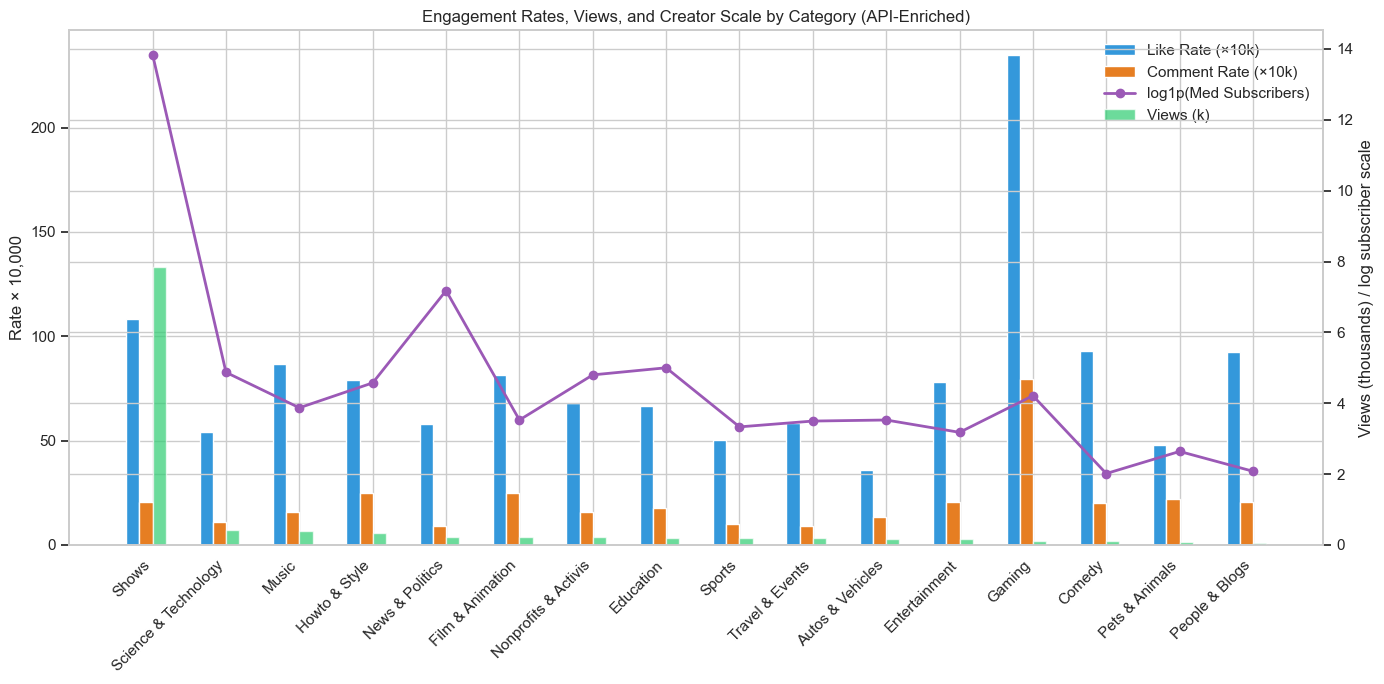

,Avg Like Rate,Med Like Rate,Avg Comment Rate,Med Comment Rate,Avg Views,Med Views,Avg Engagement,Med Engagement,Med Subscribers,yt_subscriber_count_mean,Med Uploads,yt_channel_video_count_mean,Med Channel Views,yt_channel_view_count_mean,Med Video Length (sec),yt_duration_sec_mean,Med Video Age (days),video_age_days_mean,Med Channel Age (days),channel_age_days_mean,Avg Thumb Brightness,thumb_mean_brightness_median,Avg Thumb Colorfulness,thumb_colorfulness_median
category,,,,,,,,,,,,,,,,,,,,,,,,
Shows,0.010817,0.007162,0.002048,0.0005,226126.777778,7854.5,4.421813,4.094345,1016500.0,1.299457e+07,7997.0,44341.277778,540121730.5,1.283870e+10,571.0,714.500000,4768.0,4734.722222,5872.0,5945.777778,86.265783,82.447845,58.345849,46.658305
Science & Technology,0.005399,0.001695,0.001122,0.0000,12480.841727,427.0,1.461065,1.098612,129.5,2.335962e+05,62.5,1536.507194,87959.0,6.114629e+07,143.0,333.093525,4929.0,5067.201439,5617.0,5639.230216,103.938039,103.115082,41.125442,37.905294
Music,0.008680,0.004556,0.001555,0.0000,126966.233978,392.0,1.893343,1.386294,47.0,1.828614e+04,30.0,739.614106,43273.0,1.295446e+07,210.0,260.937267,5198.0,5288.727026,5919.0,5897.364869,74.708329,72.352005,42.520651,38.061788
Howto & Style,0.007894,0.001652,0.002504,0.0000,27299.501475,342.0,1.774540,1.098612,96.0,4.531262e+04,48.0,1578.188791,63826.0,1.416841e+07,144.0,216.781711,4997.0,5129.935103,5574.0,5665.200590,104.260060,103.420830,44.339189,40.711170
News & Politics,0.005781,0.001142,0.000924,0.0000,29510.155803,229.0,1.211044,0.693147,1310.0,5.596005e+05,770.5,25449.038462,1057701.0,4.132641e+08,147.0,279.871224,4980.0,5094.915739,5812.5,5783.724359,94.521343,94.794754,42.503374,39.219580
Film & Animation,0.008149,0.002480,0.002505,0.0000,40054.389744,226.0,1.615276,1.098612,33.0,4.271621e+04,26.0,667.938462,27478.0,2.056075e+07,113.0,223.690598,5167.0,5294.553846,5753.0,5803.461538,92.637501,90.308975,39.107077,35.780662
Nonprofits & Activis,0.006780,0.002869,0.001594,0.0000,5854.972973,220.5,1.213630,0.693147,120.5,2.708069e+04,61.0,1499.576577,53536.0,1.112945e+07,225.0,545.977578,5042.0,5101.430493,5748.5,5786.590090,96.305628,95.192429,41.251199,37.393499
Education,0.006668,0.001901,0.001751,0.0000,672632.485086,199.0,1.302287,0.693147,147.5,3.859856e+04,70.5,2570.474922,83654.0,2.556014e+07,204.5,432.840125,4979.0,5097.579937,5560.0,5641.612853,104.329003,100.789787,39.991250,34.980106
Sports,0.005006,0.000284,0.001008,0.0000,8704.703673,193.0,1.004425,0.693147,27.0,3.267978e+04,59.0,3345.985294,29927.5,1.579534e+07,97.0,219.551837,5146.0,5250.332245,5915.0,5893.804739,105.409235,107.782963,40.280916,36.443412


In [20]:
# ----------------------------
# Helpers: choose best columns
# ----------------------------
def pick_col(primary, fallback):
    return primary if primary in df_eng.columns else fallback

views_col    = pick_col("yt_view_count", "views")
likes_col    = pick_col("yt_like_count", "likes")
comments_col = pick_col("yt_comment_count", "comments")

# Make sure core cols are numeric
for c in [views_col, likes_col, comments_col,
          "yt_subscriber_count", "yt_channel_video_count", "yt_channel_view_count",
          "yt_duration_sec", "thumb_mean_brightness", "thumb_colorfulness",
          "video_age_days", "channel_age_days",
          "like_rate", "comment_rate", "engagement_score"]:
    if c in df_eng.columns:
        df_eng[c] = pd.to_numeric(df_eng[c], errors="coerce")

# ----------------------------
# Aggregate: category-level stats (robust)
# ----------------------------
agg_dict = {
    "like_rate": ["mean", "median"],
    "comment_rate": ["mean", "median"],
    views_col: ["mean", "median"],
    "engagement_score": ["mean", "median"],
}

# Add API-derived creator/context vars if present
optional_vars = {
    "yt_subscriber_count": ["median", "mean"],
    "yt_channel_video_count": ["median", "mean"],
    "yt_channel_view_count": ["median", "mean"],
    "yt_duration_sec": ["median", "mean"],
    "video_age_days": ["median", "mean"],
    "channel_age_days": ["median", "mean"],
    "thumb_mean_brightness": ["mean", "median"],
    "thumb_colorfulness": ["mean", "median"],
}

for col, funcs in optional_vars.items():
    if col in df_eng.columns:
        agg_dict[col] = funcs

rate_by_cat = df_eng.groupby("category").agg(agg_dict)

# Flatten column names
rate_by_cat.columns = ["_".join([str(c) for c in tup if c]) for tup in rate_by_cat.columns]
rate_by_cat = rate_by_cat.reset_index()

# Friendly names (only for columns that exist)
rename_map = {
    "like_rate_mean": "Avg Like Rate",
    "comment_rate_mean": "Avg Comment Rate",
    f"{views_col}_mean": "Avg Views",
    "engagement_score_mean": "Avg Engagement",

    "like_rate_median": "Med Like Rate",
    "comment_rate_median": "Med Comment Rate",
    f"{views_col}_median": "Med Views",
    "engagement_score_median": "Med Engagement",

    "yt_subscriber_count_median": "Med Subscribers",
    "yt_channel_video_count_median": "Med Uploads",
    "yt_channel_view_count_median": "Med Channel Views",
    "yt_duration_sec_median": "Med Video Length (sec)",
    "video_age_days_median": "Med Video Age (days)",
    "channel_age_days_median": "Med Channel Age (days)",
    "thumb_mean_brightness_mean": "Avg Thumb Brightness",
    "thumb_colorfulness_mean": "Avg Thumb Colorfulness",
}
rate_by_cat = rate_by_cat.rename(columns={k: v for k, v in rename_map.items() if k in rate_by_cat.columns})

# Sort by a sane “size” metric: median views (fallback to mean if needed)
sort_col = "Med Views" if "Med Views" in rate_by_cat.columns else "Avg Views"
rate_by_cat = rate_by_cat.sort_values(sort_col, ascending=False).set_index("category")

# ----------------------------
# Plot: engagement rates + views + creator scale (if present)
# ----------------------------
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(rate_by_cat))
w = 0.18

# Use mean rates but show median views (more stable)
like_rate_plot = rate_by_cat["Avg Like Rate"] if "Avg Like Rate" in rate_by_cat.columns else rate_by_cat["Med Like Rate"]
com_rate_plot  = rate_by_cat["Avg Comment Rate"] if "Avg Comment Rate" in rate_by_cat.columns else rate_by_cat["Med Comment Rate"]
views_plot     = rate_by_cat["Med Views"] if "Med Views" in rate_by_cat.columns else rate_by_cat["Avg Views"]

ax.bar(x - 1.5*w, like_rate_plot * 10000, width=w, label="Like Rate (×10k)", color="#3498db")
ax.bar(x - 0.5*w, com_rate_plot  * 10000, width=w, label="Comment Rate (×10k)", color="#e67e22")

# Secondary axis: views (k)
ax2 = ax.twinx()
ax2.bar(x + 0.5*w, views_plot / 1000, width=w, label="Views (k)", color="#2ecc71", alpha=0.7)

# Optional third signal: median subscribers (scaled)
if "Med Subscribers" in rate_by_cat.columns:
    # Scale subscribers to fit visually (log-ish without changing axis)
    subs_scaled = np.log1p(rate_by_cat["Med Subscribers"])
    ax2.plot(x, subs_scaled, marker="o", linewidth=2, label="log1p(Med Subscribers)", color="#9b59b6")

ax.set_xticks(x)
ax.set_xticklabels(rate_by_cat.index, rotation=45, ha="right")
ax.set_ylabel("Rate × 10,000")
ax2.set_ylabel("Views (thousands) / log subscriber scale")

# Combine legends cleanly
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax.set_title("Engagement Rates, Views, and Creator Scale by Category (API-Enriched)")
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: show the enriched table (top 12)
# ----------------------------
display(rate_by_cat.head(12))

**Analysis.** The API-enriched feature set enables a substantially richer characterization of engagement dynamics beyond raw interaction counts. Derived engagement rates (likes and comments per view), when capped at the 99th percentile, exhibit heavy right skew, indicating that high-intensity engagement is rare and concentrated among a small subset of videos. This pattern persists across categories, reinforcing the distinction between reach (views) and depth of engagement (rates).

Creator-level attributes introduce additional structure. Subscriber counts, upload volume, and cumulative channel views display extreme dispersion, consistent with a highly unequal creator ecosystem. Categories differ markedly in typical creator scale: some domains are dominated by large, institutional channels, while others are characterized by smaller, high-variance creators. Channel and video age distributions further suggest that engagement outcomes are shaped by both platform tenure and content recency.

Contextual features extracted from the API, including channel country, video duration, title length, and thumbnail visual properties, reveal systematic but heterogeneous associations with engagement. Country-level aggregation highlights cross-regional differences in median engagement intensity, while thumbnail brightness and colorfulness vary modestly across categories, suggesting a secondary but potentially complementary role to semantic content.

---
## 7. Correlation & Relationship Analysis

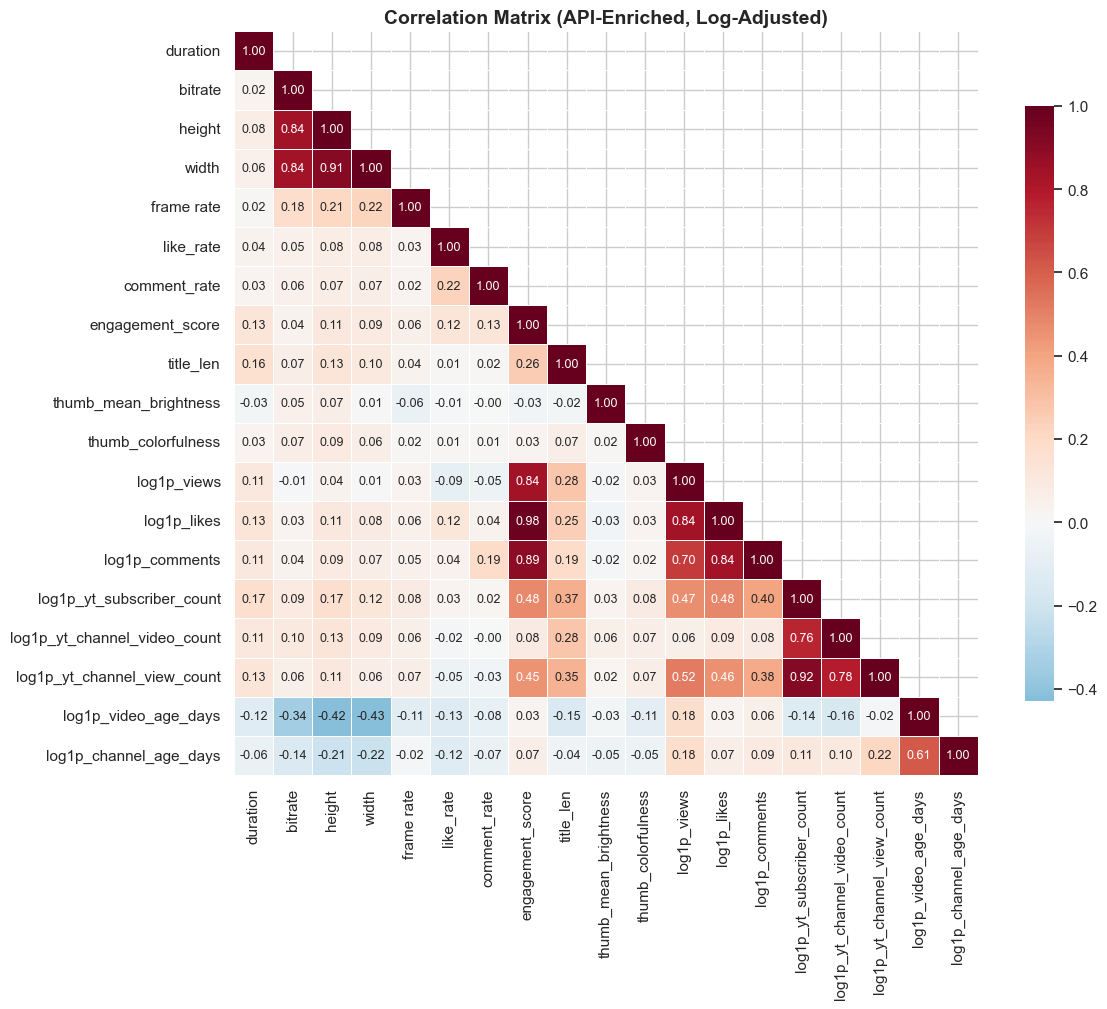

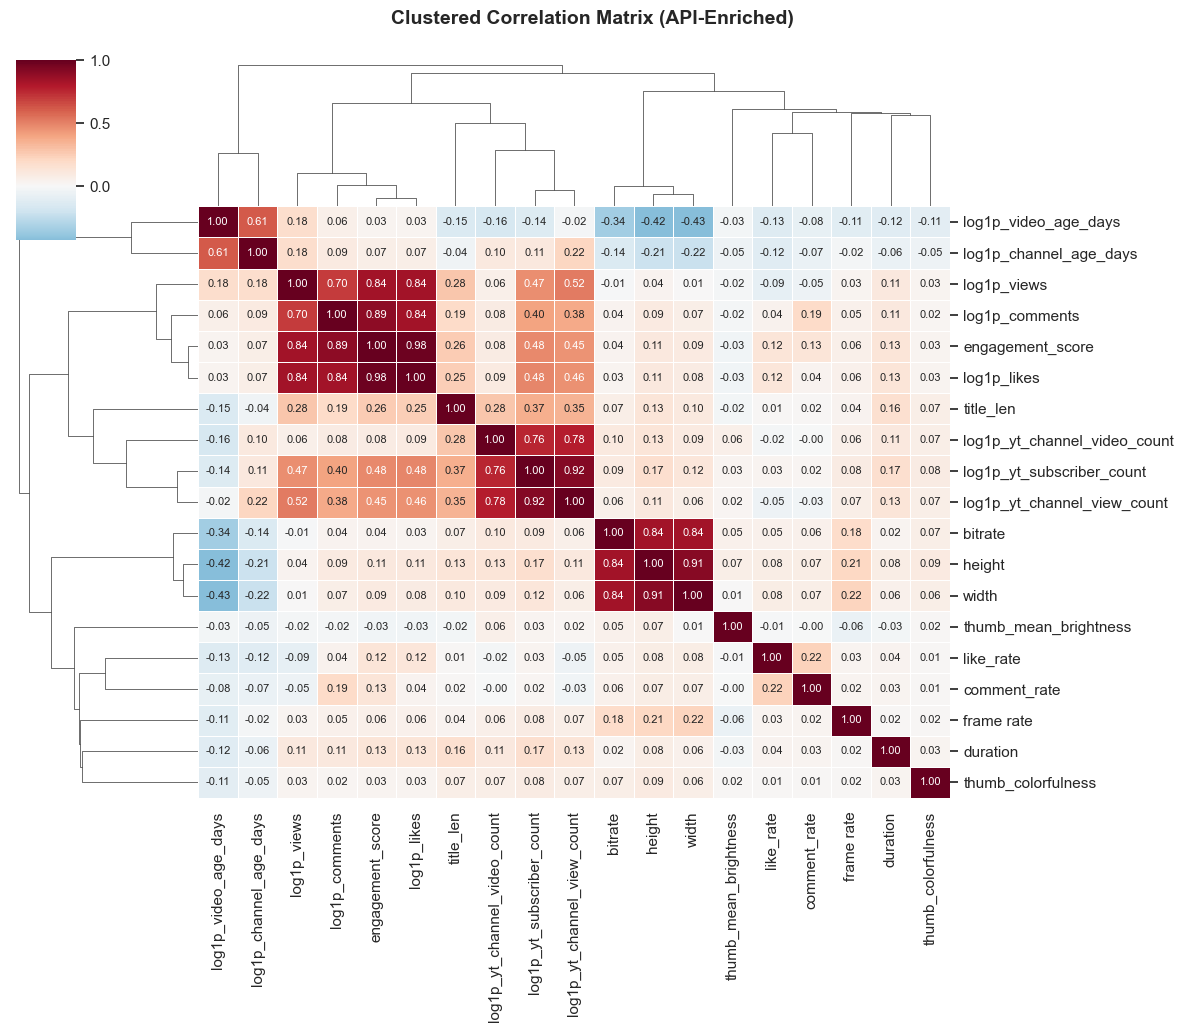

In [ ]:
# -------------------------------------------------
# Select correlation variables (API-enriched)
# -------------------------------------------------
corr_cols = [
    # Video technical
    "duration",
    "bitrate",
    "height",
    "width",
    "frame rate",

    # Engagement (raw + derived)
    "views",
    "likes",
    "comments",
    "like_rate",
    "comment_rate",
    "engagement_score",

    # Creator scale
    "yt_subscriber_count",
    "yt_channel_video_count",
    "yt_channel_view_count",

    # Temporal
    "video_age_days",
    "channel_age_days",

    # Content / text
    "title_len",
    "hashtag_count",

    # Thumbnail visuals
    "thumb_mean_brightness",
    "thumb_colorfulness",
]

# Keep only columns that actually exist
corr_cols = [c for c in corr_cols if c in df_eng.columns]

# -------------------------------------------------
# Prepare numeric + log-safe data
# -------------------------------------------------
corr_df = df_eng[corr_cols].copy()

# Force numeric
corr_df = corr_df.apply(pd.to_numeric, errors="coerce")

# Log-transform heavy-tailed variables
log_cols = [
    "views", "likes", "comments",
    "yt_subscriber_count", "yt_channel_video_count", "yt_channel_view_count",
    "video_age_days", "channel_age_days"
]

for col in log_cols:
    if col in corr_df.columns:
        corr_df[f"log1p_{col}"] = np.log1p(corr_df[col])

# Final set: drop raw heavy-tailed versions, keep logs
final_corr_cols = [
    c for c in corr_df.columns
    if not (c in log_cols)
]

corr_df = corr_df[final_corr_cols].dropna()

# -------------------------------------------------
# Correlation matrix
# -------------------------------------------------
corr_matrix = corr_df.corr()

# -------------------------------------------------
# Heatmap (lower triangle)
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9},
    ax=ax
)

ax.set_title("Correlation Matrix (API-Enriched, Log-Adjusted)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Clustered correlation (structure discovery)
# -------------------------------------------------
g = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    figsize=(12, 10),
    linewidths=0.5,
    annot_kws={"size": 8}
)

g.fig.suptitle("Clustered Correlation Matrix (API-Enriched)", y=1.03, fontsize=14, fontweight="bold")
plt.show()

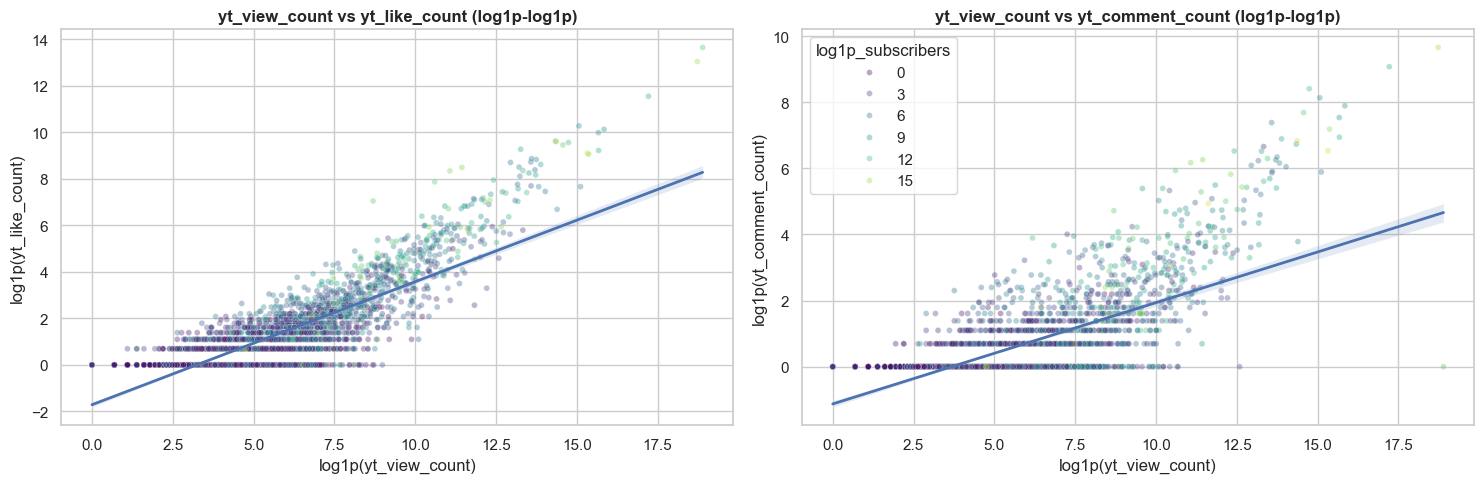

In [22]:
sns.set(style="whitegrid")

# ----------------------------
# Use API-enriched df if you have it
# ----------------------------
base = df_eng if "df_eng" in globals() else df

# Prefer yt_* counts when available
views_col    = "yt_view_count"    if "yt_view_count"    in base.columns else "views"
likes_col    = "yt_like_count"    if "yt_like_count"    in base.columns else "likes"
comments_col = "yt_comment_count" if "yt_comment_count" in base.columns else "comments"

# Optional: color by creator size (or swap to "channel_age_days", "video_age_days", etc.)
hue_col = None
if "log1p_subscribers" in base.columns:
    hue_col = "log1p_subscribers"
elif "yt_subscriber_count" in base.columns:
    base = base.copy()
    base["log1p_subscribers"] = np.log1p(pd.to_numeric(base["yt_subscriber_count"], errors="coerce"))
    hue_col = "log1p_subscribers"

# Sample for speed/readability
sample = base.sample(min(4000, len(base)), random_state=42).copy()

# Force numeric + log1p safe transforms
for c in [views_col, likes_col, comments_col]:
    sample[c] = pd.to_numeric(sample[c], errors="coerce")

sample = sample.dropna(subset=[views_col, likes_col, comments_col])

sample["log1p_views"]    = np.log1p(sample[views_col])
sample["log1p_likes"]    = np.log1p(sample[likes_col])
sample["log1p_comments"] = np.log1p(sample[comments_col])

# ----------------------------
# Plot: Views vs Likes / Views vs Comments (log1p-log1p)
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Views vs Likes
sns.scatterplot(
    data=sample,
    x="log1p_views",
    y="log1p_likes",
    hue=hue_col,
    palette="viridis" if hue_col else None,
    alpha=0.35,
    s=18,
    ax=axes[0],
    legend=False
)

sns.regplot(
    data=sample,
    x="log1p_views",
    y="log1p_likes",
    scatter=False,
    ax=axes[0],
    line_kws={"lw": 2}
)

axes[0].set_title(f"{views_col} vs {likes_col} (log1p-log1p)", fontweight="bold")
axes[0].set_xlabel(f"log1p({views_col})")
axes[0].set_ylabel(f"log1p({likes_col})")

# ---- Views vs Comments
sns.scatterplot(
    data=sample,
    x="log1p_views",
    y="log1p_comments",
    hue=hue_col,
    palette="viridis" if hue_col else None,
    alpha=0.35,
    s=18,
    ax=axes[1],
    legend=True if hue_col else False
)

sns.regplot(
    data=sample,
    x="log1p_views",
    y="log1p_comments",
    scatter=False,
    ax=axes[1],
    line_kws={"lw": 2}
)

axes[1].set_title(f"{views_col} vs {comments_col} (log1p-log1p)", fontweight="bold")
axes[1].set_xlabel(f"log1p({views_col})")
axes[1].set_ylabel(f"log1p({comments_col})")

# If hue exists, give a readable legend
if hue_col:
    axes[1].legend(title=hue_col, loc="best", frameon=True)

plt.tight_layout()
plt.show()

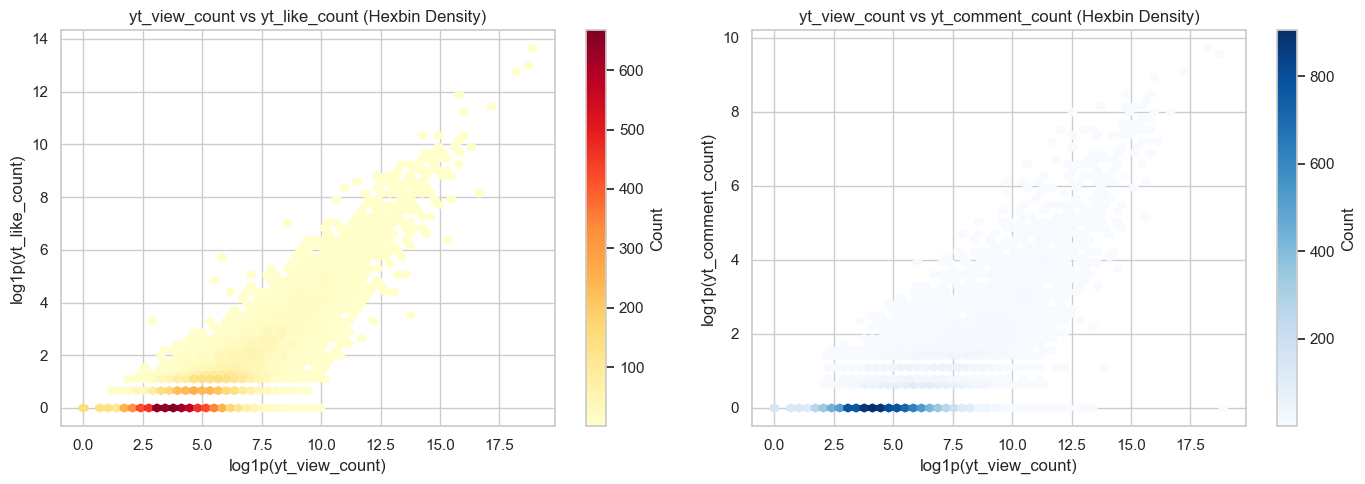

In [25]:
# ----------------------------
# Use API-enriched df if available
# ----------------------------
base = df_eng if "df_eng" in globals() else df

# Prefer yt_* counts when available
views_col    = "yt_view_count"    if "yt_view_count"    in base.columns else "views"
likes_col    = "yt_like_count"    if "yt_like_count"    in base.columns else "likes"
comments_col = "yt_comment_count" if "yt_comment_count" in base.columns else "comments"

# Safe numeric coercion
plot_df = base[[views_col, likes_col, comments_col]].copy()
for c in [views_col, likes_col, comments_col]:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

plot_df = plot_df.dropna(subset=[views_col, likes_col, comments_col])

# Log1p transforms (handles zeros)
x = np.log1p(plot_df[views_col].clip(lower=0))
y_likes = np.log1p(plot_df[likes_col].clip(lower=0))
y_comments = np.log1p(plot_df[comments_col].clip(lower=0))

# ----------------------------
# Hexbin plots
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h1 = axes[0].hexbin(x, y_likes, gridsize=55, cmap="YlOrRd", mincnt=1)
plt.colorbar(h1, ax=axes[0], label="Count")
axes[0].set_xlabel(f"log1p({views_col})")
axes[0].set_ylabel(f"log1p({likes_col})")
axes[0].set_title(f"{views_col} vs {likes_col} (Hexbin Density)")

h2 = axes[1].hexbin(x, y_comments, gridsize=55, cmap="Blues", mincnt=1)
plt.colorbar(h2, ax=axes[1], label="Count")
axes[1].set_xlabel(f"log1p({views_col})")
axes[1].set_ylabel(f"log1p({comments_col})")
axes[1].set_title(f"{views_col} vs {comments_col} (Hexbin Density)")

plt.tight_layout()
plt.show()

**Analysis.** 

The expanded correlation analysis reveals a clear hierarchical structure among engagement, creator-scale, temporal, and technical variables. As expected, views, likes, comments, and the composite engagement score form a tightly coupled cluster, with near-collinearity among log-transformed engagement counts. This confirms that these metrics largely capture the same latent construct of audience response, implying that downstream models should avoid treating them as independent predictors and instead rely on dimensionality reduction, feature selection, or regularisation.

Creator-scale variables derived from the API (subscriber count, channel uploads, and channel views) form a second, strongly correlated block that is moderately associated with engagement outcomes but not deterministically so. The scatter and hexbin plots illustrate substantial dispersion at fixed subscriber levels, indicating that creator size increases potential reach but does not guarantee proportional engagement. This supports modelling strategies that treat creator scale as a contextual baseline rather than a direct proxy for performance.

Temporal features exhibit distinct and interpretable patterns. Video age shows a negative association with engagement and view counts, consistent with content decay, while channel age correlates positively with creator scale but weakly with per-video engagement. These findings justify explicitly separating content-level dynamics from creator maturity effects in predictive frameworks.

Technical attributes (resolution, bitrate, frame rate, duration) cluster together with strong internal correlations but display weak relationships with engagement metrics. This suggests that production quality follows standardized conventions and contributes limited marginal explanatory power once content type and creator context are controlled. Thumbnail visual features show modest correlations with engagement and remain largely orthogonal to creator scale, positioning them as complementary, non-redundant features.

---
## 8. Outlier Detection & Robustness

In [26]:
# ----------------------------
# Helper
# ----------------------------
def count_outliers_iqr(series):
    series = series.dropna()
    if series.empty:
        return np.nan, np.nan
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((series < low) | (series > high)).sum()
    pct = round(outliers / len(series) * 100, 2)
    return outliers, pct

# ----------------------------
# Choose base dataframe
# ----------------------------
base = df_eng if "df_eng" in globals() else df

# Prefer yt_* counts
views_col    = "yt_view_count"    if "yt_view_count"    in base.columns else "views"
likes_col    = "yt_like_count"    if "yt_like_count"    in base.columns else "likes"
comments_col = "yt_comment_count" if "yt_comment_count" in base.columns else "comments"

# ----------------------------
# Columns to test
# ----------------------------
outlier_vars = {
    # Raw engagement
    views_col: "Views",
    likes_col: "Likes",
    comments_col: "Comments",

    # Rates (already capped)
    "like_rate_cap": "Like Rate (capped)",
    "comment_rate_cap": "Comment Rate (capped)",

    # Creator scale (log)
    "log1p_subscribers": "Subscribers (log1p)",
    "log1p_channel_uploads": "Channel Uploads (log1p)",

    # Time
    "video_age_days": "Video Age (days)",
    "channel_age_days": "Channel Age (days)",

    # Content
    "log1p_video_len_sec": "Video Length (log1p)",
    "title_len": "Title Length",

    # Visuals
    "thumb_mean_brightness": "Thumbnail Brightness",
    "thumb_colorfulness": "Thumbnail Colorfulness"
}

# Keep only columns that exist
outlier_vars = {k: v for k, v in outlier_vars.items() if k in base.columns}

# ----------------------------
# Compute outliers
# ----------------------------
rows = []
for col, label in outlier_vars.items():
    outliers, pct = count_outliers_iqr(pd.to_numeric(base[col], errors="coerce"))
    rows.append({
        "Variable": label,
        "Column": col,
        "Outliers (IQR)": outliers,
        "Pct of Observations (%)": pct
    })

outlier_summary = pd.DataFrame(rows).sort_values(
    "Pct of Observations (%)", ascending=False
)

outlier_summary

,Variable,Column,Outliers (IQR),Pct of Observations (%)
4,Comment Rate (capped),comment_rate_cap,3137,19.61
0,Views,yt_view_count,2868,16.40
2,Comments,yt_comment_count,2412,14.93
1,Likes,yt_like_count,2565,14.85
3,Like Rate (capped),like_rate_cap,1798,10.51
12,Thumbnail Colorfulness,thumb_colorfulness,563,3.22
10,Title Length,title_len,415,2.36
6,Channel Uploads (log1p),log1p_channel_uploads,353,2.02
5,Subscribers (log1p),log1p_subscribers,298,1.70
9,Video Length (log1p),log1p_video_len_sec,168,0.96


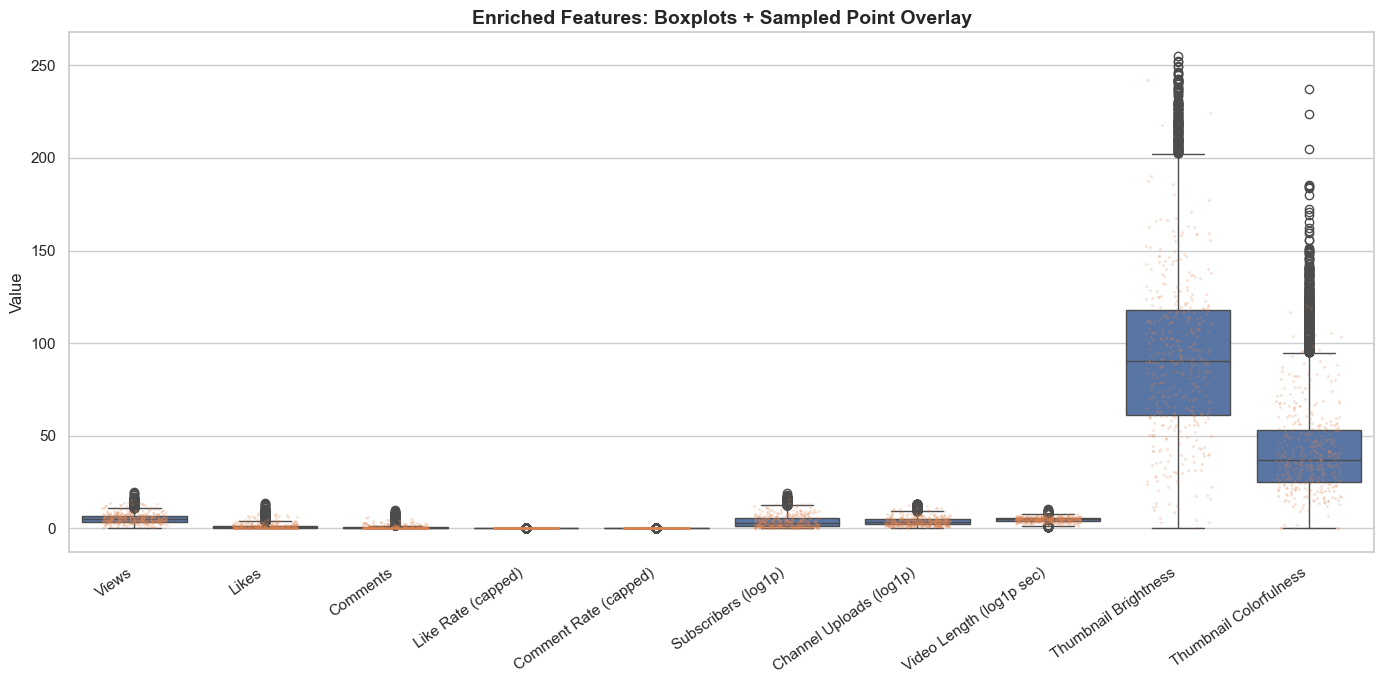

In [27]:
sns.set(style="whitegrid")

# Use df_eng if available, else df
base = df_eng if "df_eng" in globals() else df

# Prefer yt_* counts
views_col    = "yt_view_count"    if "yt_view_count"    in base.columns else "views"
likes_col    = "yt_like_count"    if "yt_like_count"    in base.columns else "likes"
comments_col = "yt_comment_count" if "yt_comment_count" in base.columns else "comments"

# Variables to plot: (column, label, transform)
# transform: "log1p" or "none"
plot_specs = [
    (views_col, "Views", "log1p"),
    (likes_col, "Likes", "log1p"),
    (comments_col, "Comments", "log1p"),
    ("like_rate_cap", "Like Rate (capped)", "none"),
    ("comment_rate_cap", "Comment Rate (capped)", "none"),
    ("log1p_subscribers", "Subscribers (log1p)", "none"),
    ("log1p_channel_uploads", "Channel Uploads (log1p)", "none"),
    ("log1p_video_len_sec", "Video Length (log1p sec)", "none"),
    ("thumb_mean_brightness", "Thumbnail Brightness", "none"),
    ("thumb_colorfulness", "Thumbnail Colorfulness", "none"),
]

# Keep only existing columns
plot_specs = [(c, lab, tr) for (c, lab, tr) in plot_specs if c in base.columns]

# --- build a long dataframe for seaborn ---
rows = []
for col, label, tr in plot_specs:
    s = pd.to_numeric(base[col], errors="coerce")
    if tr == "log1p":
        s = np.log1p(s.clip(lower=0))
    rows.append(pd.DataFrame({"Metric": label, "Value": s}))

plot_df = pd.concat(rows, ignore_index=True).dropna(subset=["Value"])

# Optional: sample for strip overlay (keeps plots readable)
N_STRIP = min(4000, len(plot_df))
strip_df = plot_df.sample(N_STRIP, random_state=42) if len(plot_df) > N_STRIP else plot_df

# --- plot ---
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=plot_df,
    x="Metric",
    y="Value",
    showfliers=True
)

sns.stripplot(
    data=strip_df,
    x="Metric",
    y="Value",
    size=2,
    alpha=0.25,
    jitter=0.25
)

plt.title("Enriched Features: Boxplots + Sampled Point Overlay", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

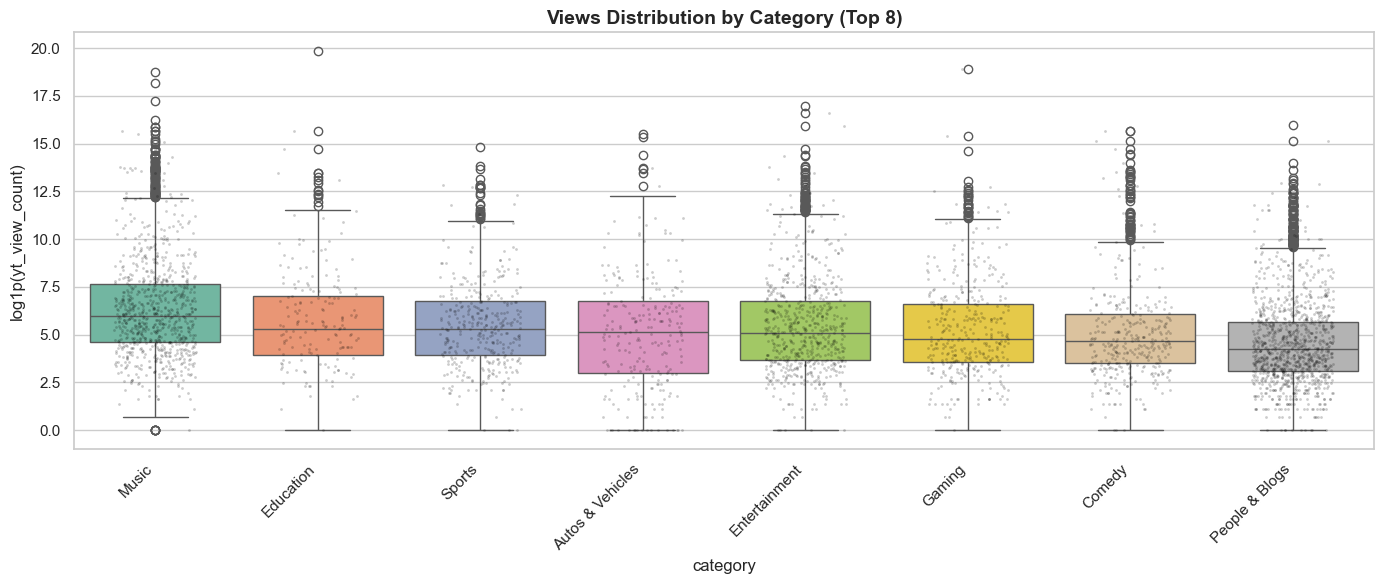

In [28]:
sns.set(style="whitegrid")

# Use df_eng if you have it (recommended), else df
base = df_eng if "df_eng" in globals() else df

# Prefer API-enriched views when available
views_col = "yt_view_count" if "yt_view_count" in base.columns else "views"

# ----------------------------
# Pick top categories
# ----------------------------
TOP_N = 8
top_categories = base["category"].value_counts().head(TOP_N).index.tolist()

df_top = base[base["category"].isin(top_categories)].copy()
df_top = df_top.dropna(subset=["category", views_col])

# Safe numeric + log transform
df_top[views_col] = pd.to_numeric(df_top[views_col], errors="coerce")
df_top["log_views"] = np.log1p(df_top[views_col].clip(lower=0))

# Optional: order categories by median views (better visual)
cat_order = (
    df_top.groupby("category")["log_views"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Optional: downsample for strip overlay (keeps it readable)
N_STRIP = min(4000, len(df_top))
df_strip = df_top.sample(N_STRIP, random_state=42) if len(df_top) > N_STRIP else df_top

# ----------------------------
# Plot: Box + sampled points
# ----------------------------
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_top,
    x="category",
    y="log_views",
    order=cat_order,
    palette="Set2",
    showfliers=True
)

sns.stripplot(
    data=df_strip,
    x="category",
    y="log_views",
    order=cat_order,
    color="black",
    alpha=0.20,
    jitter=0.25,
    size=2
)

plt.xticks(rotation=45, ha="right")
plt.ylabel(f"log1p({views_col})")
plt.title(f"Views Distribution by Category (Top {TOP_N})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis.** 

Outlier diagnostics and distributional visualisations confirm that engagement-related variables exhibit pronounced heavy-tailed behaviour. Views, likes, comments, and derived engagement rates show substantial proportions of observations beyond conventional 1.5×IQR thresholds, reflecting the dominance of rare but extreme viral outcomes. Box plots with sampled point overlays illustrate that this tail behaviour is not uniform across features: raw engagement counts and rate-based metrics are especially skewed, while creator-scale variables (subscriber count, upload volume) and thumbnail features display more moderate dispersion. Category-stratified box plots further indicate that outlier prevalence and spread vary systematically by content type, suggesting heterogeneous engagement regimes rather than a single global distribution. These findings motivate the use of log transformations, robust estimators, and potentially mixture or hurdle-style models that explicitly separate typical performance from extreme outcomes. Any outlier handling strategy should therefore be explicitly justified, as aggressive trimming risks eliminating the very observations that define platform dynamics and audience amplification.

---
## 9. Video Quality & Resolution Analysis

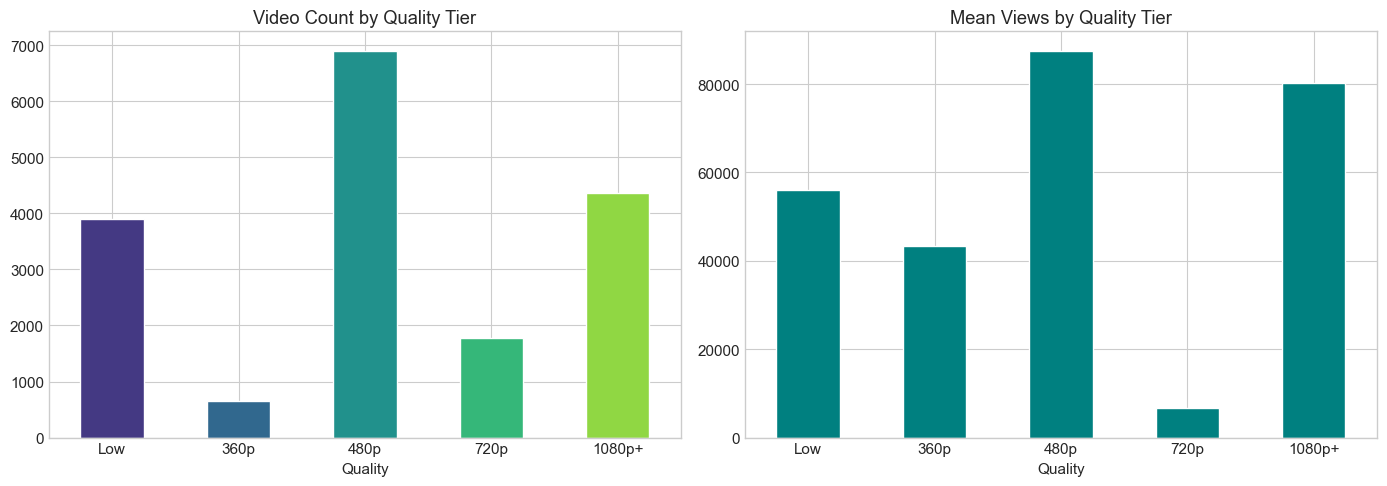

In [111]:
# Aspect ratio and quality tier
df_res = df.copy()
df_res['aspect_ratio'] = df_res['width'] / (df_res['height'] + 1e-6)
df_res['pixels'] = df_res['width'] * df_res['height']

def quality_tier(row):
    w, h = row['width'], row['height']
    if w >= 1920 or h >= 1080: return '1080p+'  
    if w >= 1280 or h >= 720: return '720p'
    if w >= 854 or h >= 480: return '480p'
    if w >= 640 or h >= 360: return '360p'
    return 'Low'

df_res['quality_tier'] = df_res.apply(quality_tier, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quality_order = ['Low', '360p', '480p', '720p', '1080p+']
qt_counts = df_res['quality_tier'].value_counts().reindex(quality_order).dropna()
if len(qt_counts) > 0:
    qt_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', len(qt_counts)))
axes[0].set_title('Video Count by Quality Tier')
axes[0].set_xlabel('Quality')
axes[0].tick_params(axis='x', rotation=0)

mean_views_qt = df_res.groupby('quality_tier')['views'].mean().reindex(quality_order).dropna()
if len(mean_views_qt) > 0:
    mean_views_qt.plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Mean Views by Quality Tier')
axes[1].set_xlabel('Quality')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Analysis.** 

The relationship between video quality tier, content supply, and audience reach exhibits clear structure rather than a simple monotonic pattern. Video counts are concentrated in mid-range quality tiers, particularly 480p and 1080+, indicating that most creators converge on technically adequate but not uniformly high production standards. Mean views vary substantially across tiers: higher-resolution content (1080+) is associated with elevated average view counts, suggesting that production quality may support discoverability or viewer retention at scale. However, the strongest mean performance is not strictly aligned with the highest quality tier alone, implying diminishing returns to technical upgrades beyond a baseline threshold. The relatively low mean views for certain intermediate tiers further suggest that content relevance and creator scale interact with quality rather than being dominated by it. These findings support modelling strategies that treat quality as a contributing but non-deterministic feature, and motivate interaction terms between quality, creator size, and content category in engagement prediction models.

---
## 10. Text Features (Title & Hashtags)

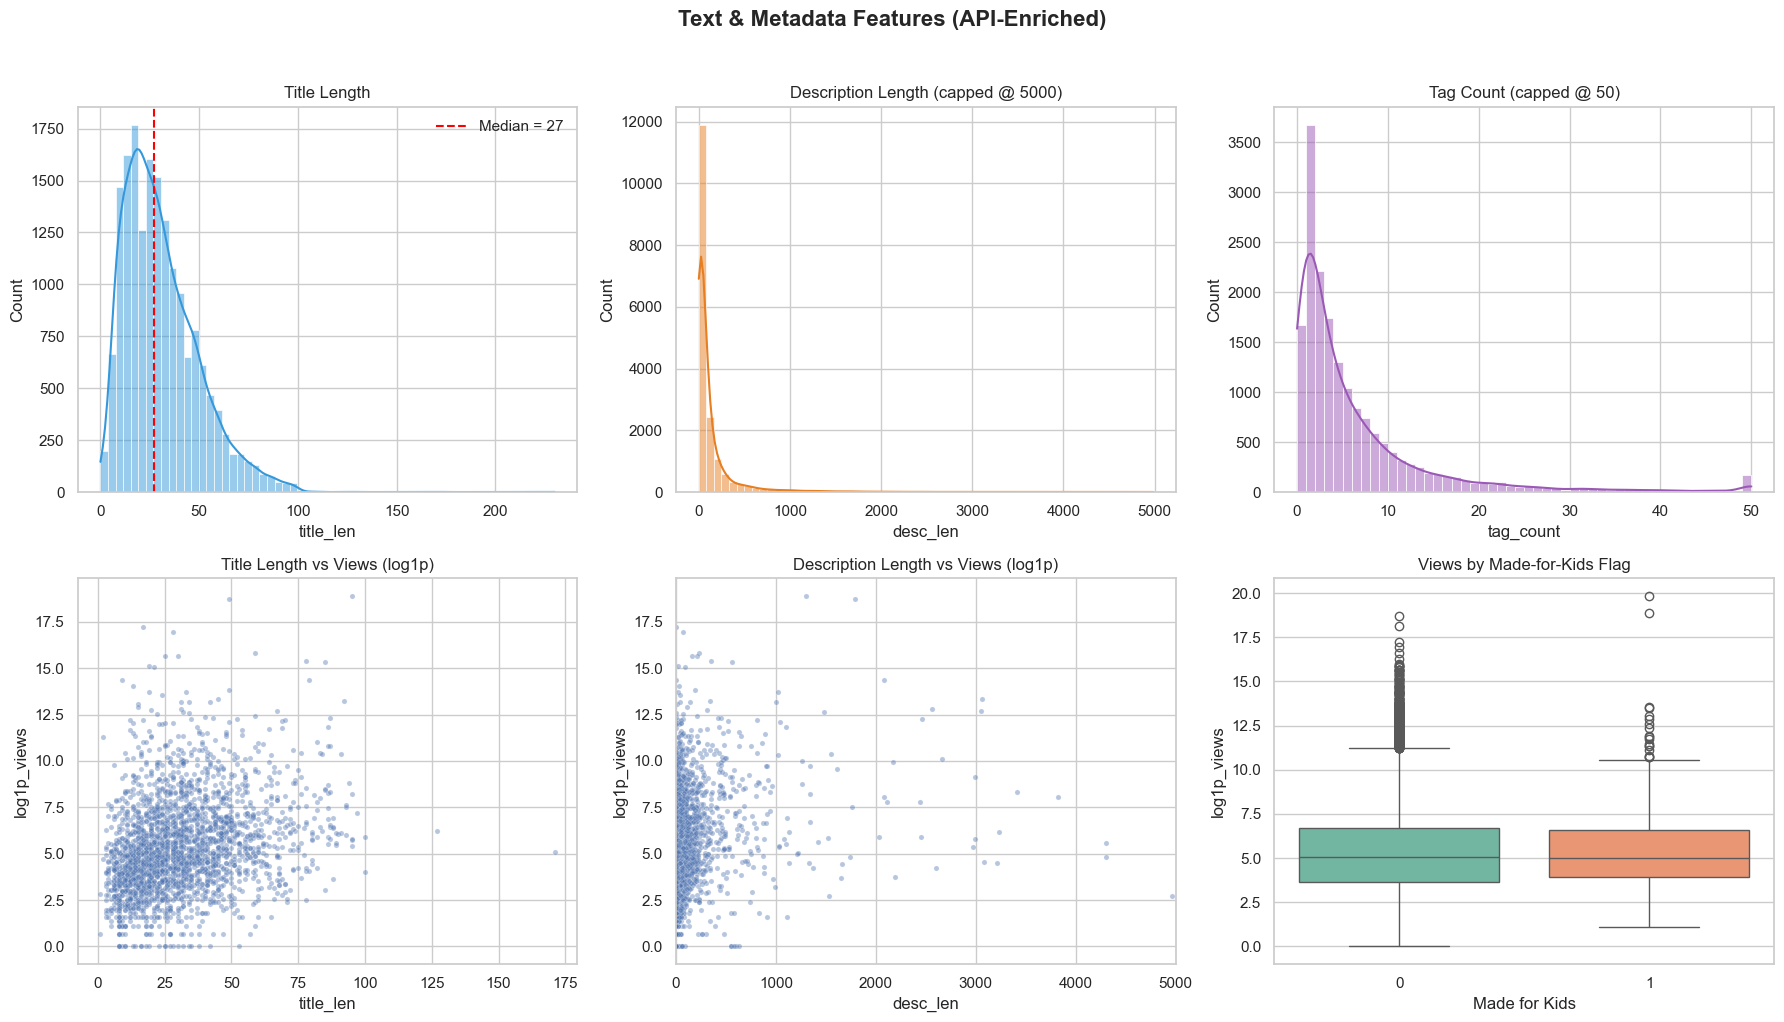

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df_txt = df.copy()

# ----------------------------
# Prefer API text fields when available
# ----------------------------
title_col = "yt_title" if "yt_title" in df_txt.columns else "title"
desc_col  = "yt_description" if "yt_description" in df_txt.columns else "description"
tags_col  = "yt_tags_json" if "yt_tags_json" in df_txt.columns else "hashtags"

# ----------------------------
# Core text features
# ----------------------------
df_txt["title_len"] = df_txt[title_col].fillna("").astype(str).str.len()
df_txt["desc_len"]  = df_txt[desc_col].fillna("").astype(str).str.len()

# Tag count (JSON list or comma-separated fallback)
def count_tags(x):
    if pd.isna(x) or str(x).strip() == "":
        return 0
    s = str(x)
    if s.startswith("["):  # JSON-like
        return s.count(",") + 1
    return len([t for t in s.split(",") if t.strip()])

df_txt["tag_count"] = df_txt[tags_col].apply(count_tags)

# ----------------------------
# Language & policy indicators
# ----------------------------
if "yt_default_language" in df_txt.columns:
    df_txt["has_default_lang"] = df_txt["yt_default_language"].notna().astype(int)
else:
    df_txt["has_default_lang"] = 0

if "yt_default_audio_language" in df_txt.columns:
    df_txt["has_audio_lang"] = df_txt["yt_default_audio_language"].notna().astype(int)
else:
    df_txt["has_audio_lang"] = 0

if "yt_made_for_kids" in df_txt.columns:
    df_txt["made_for_kids"] = df_txt["yt_made_for_kids"].fillna(False).astype(int)
else:
    df_txt["made_for_kids"] = 0

# ----------------------------
# Engagement target (safe)
# ----------------------------
views_col = "yt_view_count" if "yt_view_count" in df_txt.columns else "views"
df_txt[views_col] = pd.to_numeric(df_txt[views_col], errors="coerce")
df_txt["log1p_views"] = np.log1p(df_txt[views_col])

# ----------------------------
# Plotting
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Title length
sns.histplot(df_txt["title_len"], bins=60, kde=True, ax=axes[0, 0], color="#3498db")
axes[0, 0].axvline(df_txt["title_len"].median(), color="red", ls="--",
                   label=f"Median = {df_txt['title_len'].median():.0f}")
axes[0, 0].set_title("Title Length")
axes[0, 0].legend()

# Description length (cap extreme tails)
sns.histplot(df_txt["desc_len"].clip(upper=5000), bins=60, kde=True,
             ax=axes[0, 1], color="#e67e22")
axes[0, 1].set_title("Description Length (capped @ 5000)")

# Tag count
sns.histplot(df_txt["tag_count"].clip(upper=50), bins=50, kde=True,
             ax=axes[0, 2], color="#9b59b6")
axes[0, 2].set_title("Tag Count (capped @ 50)")

# ----------------------------
# Text features vs engagement (sampled)
# ----------------------------
sample_txt = df_txt.sample(min(2500, len(df_txt)), random_state=42)

sns.scatterplot(
    data=sample_txt,
    x="title_len",
    y="log1p_views",
    alpha=0.4,
    s=14,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Title Length vs Views (log1p)")

sns.scatterplot(
    data=sample_txt,
    x="desc_len",
    y="log1p_views",
    alpha=0.4,
    s=14,
    ax=axes[1, 1]
)
axes[1, 1].set_xlim(0, 5000)
axes[1, 1].set_title("Description Length vs Views (log1p)")

sns.boxplot(
    data=df_txt,
    x="made_for_kids",
    y="log1p_views",
    ax=axes[1, 2],
    palette="Set2"
)
axes[1, 2].set_title("Views by Made-for-Kids Flag")
axes[1, 2].set_xlabel("Made for Kids")

plt.suptitle("Text & Metadata Features (API-Enriched)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Analysis.** 

Textual metadata features capture aspects of creator effort, optimisation behaviour, and platform compliance rather than direct content quality. Title length exhibits a right-skewed distribution with a clear central tendency, suggesting convergence toward a common presentation norm rather than aggressive experimentation. Description length and tag count are substantially more skewed, indicating heterogeneity in how creators leverage metadata fields.

Scatter plots of title and description length against log-transformed views reveal no strong monotonic relationship, implying that metadata verbosity alone is not a primary driver of engagement. Instead, these features likely play a secondary or conditional role, interacting with category, creator scale, or recommendation dynamics. The distributional difference observed for made-for-kids content further suggests that policy and audience constraints shape engagement outcomes independently of textual richness.

---
## 11. Key Findings Summary

**Summary and Implications.** 

The exploratory analysis reveals several structural properties of the API-enriched YouTube dataset with direct implications for modelling and inference. Engagement outcomes (views, likes, comments) display extreme right skew and heavy-tailed behaviour; log transformations and robust estimators are therefore necessary to stabilise variance and avoid domination by viral outliers. Derived engagement rates, capped at the 99th percentile, provide complementary signals that decouple interaction intensity from sheer exposure and are better suited for comparative or predictive analyses.

Content category emerges as a major axis of heterogeneity, affecting both scale (raw views) and depth (like and comment rates). This motivates category-aware modelling strategies, stratification, or interaction terms rather than a single pooled specification. Creator-level attributes exhibit large dispersion and strong correlations with engagement outcomes, indicating that creator scale represents a latent factor that must be explicitly controlled for to avoid confounding.

In contrast, technical video attributes such as resolution, bitrate, and frame rate show limited direct association with engagement once scale effects are accounted for, suggesting that production quality alone is insufficient to explain performance differences. Thumbnail brightness and colorfulness exhibit meaningful variation but weak linear correlations with engagement, implying potential non-linear or interaction effects rather than simple marginal influence.

The correlation structure among engagement metrics confirms substantial redundancy between views, likes, and comments, supporting dimensionality reduction, regularisation, or careful outcome selection in downstream models. Finally, missingness is non-trivial and highly structured, particularly for channel-level metadata such as country, requiring explicit handling and documentation to avoid biased inference. Collectively, these findings establish a rigorous empirical foundation for subsequent predictive modelling, causal exploration, and validation.

In [34]:
import numpy as np
import pandas as pd

# ----------------------------
# Helper: prefer yt_* if present
# ----------------------------
def pick_col(primary, fallback, df_):
    return primary if primary in df_.columns else fallback

views_col    = pick_col("yt_view_count", "views", df)
likes_col    = pick_col("yt_like_count", "likes", df)
comments_col = pick_col("yt_comment_count", "comments", df)
title_col    = pick_col("yt_title", "title", df)
desc_col     = pick_col("yt_description", "description", df)
dur_col      = pick_col("yt_duration_sec", "duration", df)

# ----------------------------
# Make a light copy + safe numeric casting
# ----------------------------
df_sum = df.copy()

num_cols = [
    views_col, likes_col, comments_col,
    dur_col, "bitrate", "width", "height", "frame rate", "frame_rate",
    "yt_subscriber_count", "yt_channel_video_count", "yt_channel_view_count",
    "thumb_mean_brightness", "thumb_colorfulness"
]
for c in num_cols:
    if c in df_sum.columns:
        df_sum[c] = pd.to_numeric(df_sum[c], errors="coerce")

# ----------------------------
# Derived features for summary (only if possible)
# ----------------------------
# Rates + engagement score
df_sum["like_rate"] = df_sum[likes_col] / df_sum[views_col].replace(0, np.nan)
df_sum["comment_rate"] = df_sum[comments_col] / df_sum[views_col].replace(0, np.nan)

if df_sum["like_rate"].notna().any():
    df_sum["like_rate_cap"] = df_sum["like_rate"].clip(upper=df_sum["like_rate"].quantile(0.99))
else:
    df_sum["like_rate_cap"] = np.nan

if df_sum["comment_rate"].notna().any():
    df_sum["comment_rate_cap"] = df_sum["comment_rate"].clip(upper=df_sum["comment_rate"].quantile(0.99))
else:
    df_sum["comment_rate_cap"] = np.nan

df_sum["engagement_score"] = np.log1p(df_sum[likes_col].fillna(0) + 2 * df_sum[comments_col].fillna(0))

# Text features
df_sum["title_len"] = df_sum[title_col].fillna("").astype(str).str.len()
df_sum["desc_len"]  = df_sum[desc_col].fillna("").astype(str).str.len()

# Hashtags + tags (if present)
if "hashtags" in df_sum.columns:
    df_sum["hashtag_count"] = (
        df_sum["hashtags"]
        .fillna("")
        .apply(lambda x: len([h for h in str(x).split(",") if h.strip()]) if str(x).strip() else 0)
    )
else:
    df_sum["hashtag_count"] = np.nan

if "yt_tags_json" in df_sum.columns:
    def count_tags(x):
        if pd.isna(x) or str(x).strip() == "":
            return 0
        s = str(x).strip()
        if s.startswith("[") and s.endswith("]"):
            return max(0, s.count(",") + 1) if len(s) > 2 else 0
        return len([t for t in s.split(",") if t.strip()])
    df_sum["tag_count"] = df_sum["yt_tags_json"].apply(count_tags)
else:
    df_sum["tag_count"] = np.nan

# Time features (video/channel age)
if "yt_published_at" in df_sum.columns:
    df_sum["yt_published_at_dt"] = pd.to_datetime(df_sum["yt_published_at"], errors="coerce", utc=True)
else:
    df_sum["yt_published_at_dt"] = pd.NaT

if "yt_channel_published_at" in df_sum.columns:
    df_sum["yt_channel_published_at_dt"] = pd.to_datetime(df_sum["yt_channel_published_at"], errors="coerce", utc=True)
else:
    df_sum["yt_channel_published_at_dt"] = pd.NaT

ref_time = df_sum["yt_published_at_dt"].max()
if pd.isna(ref_time):
    ref_time = pd.Timestamp.utcnow()

df_sum["video_age_days"] = (ref_time - df_sum["yt_published_at_dt"]).dt.days
df_sum["channel_age_days"] = (ref_time - df_sum["yt_channel_published_at_dt"]).dt.days

# Correlation helpers
def safe_corr(a, b):
    if a not in df_sum.columns or b not in df_sum.columns:
        return np.nan
    s = df_sum[[a, b]].dropna()
    return np.nan if len(s) < 3 else s[a].corr(s[b])

# Formatting helpers
def fmt_int(x):
    return "NA" if pd.isna(x) else f"{int(x):,}"

def fmt_float(x, nd=4):
    return "NA" if pd.isna(x) else f"{x:.{nd}f}"

# ----------------------------
# PRINT SUMMARY
# ----------------------------
print("=" * 70)
print("EDA SUMMARY — YouTube Video Dataset (API-Enriched)")
print("=" * 70)

print(f"\n📊 Dataset: {len(df_sum):,} videos, {df_sum.shape[1]} columns")

# Categories
if "category" in df_sum.columns:
    print(f"\n📌 Categories: {df_sum['category'].nunique(dropna=True)} unique")
    print(f"   Top 5: {list(df_sum['category'].value_counts().head(5).index)}")
else:
    print("\n📌 Categories: (missing 'category' column)")

# Views summary (using best column)
print(f"\n👀 Views ({views_col}): min={fmt_int(df_sum[views_col].min())}, "
      f"max={fmt_int(df_sum[views_col].max())}, median={fmt_int(df_sum[views_col].median())}")

# Engagement correlations
print(f"\n📌 Correlations (raw):")
print(f"   views-likes:    {fmt_float(safe_corr(views_col, likes_col), 3)}")
print(f"   views-comments: {fmt_float(safe_corr(views_col, comments_col), 3)}")
print(f"   likes-comments: {fmt_float(safe_corr(likes_col, comments_col), 3)}")

# Derived rates summary
print("\n📈 Derived engagement (rates capped @ 99th pct):")
print(f"   like_rate_cap median:    {fmt_float(df_sum['like_rate_cap'].median(), 5)}")
print(f"   comment_rate_cap median: {fmt_float(df_sum['comment_rate_cap'].median(), 5)}")
print(f"   engagement_score median: {fmt_float(df_sum['engagement_score'].median(), 3)}")

# Creator scale
if "yt_subscriber_count" in df_sum.columns:
    print("\n🧑‍🎤 Creator scale (API):")
    print(f"   Subscribers: median={fmt_int(df_sum['yt_subscriber_count'].median())}, "
          f"mean={fmt_int(df_sum['yt_subscriber_count'].mean())}")
if "yt_channel_video_count" in df_sum.columns:
    print(f"   Uploads:      median={fmt_int(df_sum['yt_channel_video_count'].median())}, "
          f"mean={fmt_int(df_sum['yt_channel_video_count'].mean())}")
if "yt_channel_view_count" in df_sum.columns:
    print(f"   Channel views: median={fmt_int(df_sum['yt_channel_view_count'].median())}, "
          f"mean={fmt_int(df_sum['yt_channel_view_count'].mean())}")

# Technical / video length
if dur_col in df_sum.columns:
    print(f"\n⏱️ Video length ({dur_col}): median={fmt_int(df_sum[dur_col].median())}, mean={fmt_int(df_sum[dur_col].mean())}")
if "bitrate" in df_sum.columns:
    print(f"🎛️ Bitrate: median={fmt_int(df_sum['bitrate'].median())}")
if "width" in df_sum.columns and "height" in df_sum.columns:
    print(f"🖥️ Resolution: width median={fmt_int(df_sum['width'].median())}, height median={fmt_int(df_sum['height'].median())}")

# Thumbnail
if "thumb_mean_brightness" in df_sum.columns or "thumb_colorfulness" in df_sum.columns:
    print("\n🖼️ Thumbnail features:")
    if "thumb_mean_brightness" in df_sum.columns:
        print(f"   Brightness median:   {fmt_float(df_sum['thumb_mean_brightness'].median(), 2)}")
    if "thumb_colorfulness" in df_sum.columns:
        print(f"   Colorfulness median: {fmt_float(df_sum['thumb_colorfulness'].median(), 2)}")

# Time features
if df_sum["video_age_days"].notna().any() or df_sum["channel_age_days"].notna().any():
    print("\n🕒 Temporal context (derived):")
    if df_sum["video_age_days"].notna().any():
        print(f"   Video age (days):   median={fmt_int(df_sum['video_age_days'].median())}")
    if df_sum["channel_age_days"].notna().any():
        print(f"   Channel age (days): median={fmt_int(df_sum['channel_age_days'].median())}")

# Text / metadata
print("\n📝 Text & metadata:")
print(f"   title_len median:   {fmt_int(df_sum['title_len'].median())}")
print(f"   desc_len median:    {fmt_int(df_sum['desc_len'].median())}")
if df_sum["hashtag_count"].notna().any():
    print(f"   hashtag_count med:  {fmt_int(df_sum['hashtag_count'].median())}")
if df_sum["tag_count"].notna().any():
    print(f"   tag_count median:   {fmt_int(df_sum['tag_count'].median())}")

# Country missingness callout
if "yt_channel_country" in df_sum.columns:
    miss_country = int(df_sum["yt_channel_country"].isna().sum())
    miss_country_pct = miss_country / len(df_sum) * 100
    print("\n🌍 Channel country (API):")
    print(f"   Missing: {miss_country:,} ({miss_country_pct:.2f}%)  ← yes, it’s absurdly high")

# Missingness + duplicates
print(f"\n📌 Missing: {df_sum.isna().sum().sum():,} total missing values across {(df_sum.isna().sum() > 0).sum()} columns")

top_missing = (df_sum.isna().mean().sort_values(ascending=False) * 100)
top_missing = top_missing[top_missing > 0].head(8)

if len(top_missing) > 0:
    print("   Top missing (%):")
    for k, v in top_missing.items():
        print(f"   - {k}: {v:.2f}%")

if "video_id" in df_sum.columns:
    print(f"\n📌 Duplicates: {df_sum['video_id'].duplicated().sum():,} duplicate video_ids")
else:
    print("\n📌 Duplicates: (missing 'video_id' column)")

print("=" * 70)

EDA SUMMARY — YouTube Video Dataset (API-Enriched)

📊 Dataset: 17,589 videos, 58 columns

📌 Categories: 16 unique
   Top 5: ['People & Blogs', 'Music', 'Entertainment', 'Gaming', 'Sports']

👀 Views (yt_view_count): min=0, max=413,284,307, median=154

📌 Correlations (raw):
   views-likes:    0.777
   views-comments: 0.599
   likes-comments: 0.510

📈 Derived engagement (rates capped @ 99th pct):
   like_rate_cap median:    0.00168
   comment_rate_cap median: 0.00000
   engagement_score median: 0.693

🧑‍🎤 Creator scale (API):
   Subscribers: median=24, mean=75,444
   Uploads:      median=33, mean=2,875
   Channel views: median=18,280, mean=52,958,246

⏱️ Video length (yt_duration_sec): median=136, mean=243
🎛️ Bitrate: median=743
🖥️ Resolution: width median=480, height median=640

🖼️ Thumbnail features:
   Brightness median:   90.59
   Colorfulness median: 37.04

🕒 Temporal context (derived):
   Video age (days):   median=5,060
   Channel age (days): median=5,688

📝 Text & metadata:
   tit